# PetFinder
**Maestría en Ciencia de Datos · Universidad Austral · Laboratorio II**

**Emiliano Ksiazenicer / Lucas Kuringhian / Santiago Damian Turuguet / Juan Ignacio Ton Vanerio / Analia Fernanda Jaime**



## Sección 0 — Configuración Global



In [ ]:
# [F] Instalar detección y traducción de idioma
!pip install -q langdetect deep-translator
print("[OK] langdetect y deep-translator instalados")

In [ ]:
# =============================================================================
#  SECCIÓN 0 — CONFIGURACIÓN GLOBAL (RUTAS CORREGIDAS)
# =============================================================================

import os

BASE_PATH = r"C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental"

PATH_TO_TRAIN_CSV  = os.path.join(BASE_PATH, "train", "train.csv")
PATH_TO_IMAGES_DIR = os.path.join(BASE_PATH, "train_images")

SENTIMENT_DIR      = os.path.join(BASE_PATH, "train_sentiment")
METADATA_DIR       = os.path.join(BASE_PATH, "train_metadata")

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED        = 42
TEST_SIZE   = 0.20
N_SPLITS    = 5
NUM_CLASSES = 5

# ── ViT-B/16 ─────────────────────────────────────────────────────────────────
IMAGE_SIZE   = 224
VIT_BATCH    = 16
VIT_EPOCHS   = 6
VIT_LR       = 3e-4
VIT_WEIGHT_D = 1e-2
CPU_CORES    = 0

# ── DistilBERT ────────────────────────────────────────────────────────────────
BERT_BATCH   = 32
BERT_MAX_LEN = 256
BERT_EPOCHS  = 4
BERT_LR      = 3e-5
BERT_MODEL   = "distilbert-base-uncased"

# ── LightGBM CORREGIDO ────────────────────────────────────────────────────────
LGB_PARAMS_ORDINAL = {
    'objective':        'regression',
    'metric':           'rmse',
    'n_estimators':     3000,
    'learning_rate':    0.02,
    'num_leaves':       127,
    'max_depth':        8,
    'subsample':        0.75,
    'subsample_freq':   1,
    'colsample_bytree': 0.75,
    'reg_alpha':        0.3,
    'reg_lambda':       0.5,
    'min_child_samples':20,
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1,
}

LGB_PARAMS_CLF = {
    'objective':        'multiclass',
    'num_class':        5,
    'metric':           'multi_logloss',
    'n_estimators':     2000,
    'learning_rate':    0.02,
    'num_leaves':       63,
    'max_depth':        7,
    'subsample':        0.75,
    'subsample_freq':   1,
    'colsample_bytree': 0.75,
    'reg_alpha':        0.2,
    'reg_lambda':       0.5,
    'min_child_samples':30,
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1,
}

# ── Ensamblado ────────────────────────────────────────────────────────────────
TEMPERATURE_VIT  = 1.0
TEMPERATURE_BERT = 1.0
TEMPERATURE_TAB  = 1.0
CONFIDENCE_THRESHOLD = 0.40

# ── Meta-modelo LGBMRegressor — [B] ─────────────────────────────────────────
LGB_PARAMS_META = {
    'objective':        'regression',
    'metric':           'rmse',
    'n_estimators':     200,
    'learning_rate':    0.05,
    'num_leaves':       31,
    'max_depth':        4,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.5,
    'reg_lambda':       1.0,
    'min_child_samples':10,
    'random_state':     SEED,
    'n_jobs':           -1,
    'verbose':          -1,
}

# ── Check básico ──────────────────────────────────────────────────────────────
PATH_TO_WORK = os.path.join(BASE_PATH, "outputs")
os.makedirs(PATH_TO_WORK, exist_ok=True)

print(f"[OK] CSV    : {os.path.exists(PATH_TO_TRAIN_CSV)}")
print(f"[OK] Images : {os.path.exists(PATH_TO_IMAGES_DIR)}")
print(f"[OK] Work   : {PATH_TO_WORK}")

[OK] CSV    : True
[OK] Images : True
[OK] Work   : C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs


## EDA — Etapa 1: Carga y Exploración Inicial


In [ ]:
import pandas as pd

# =============================================================================
#  SECCIÓN EDA — ANÁLISIS EXPLORATORIO COMPLETO (Etapas 1–6)
# =============================================================================

# ── EDA helpers ───────────────────────────────────────────────────────────────
TEST_CSV = os.path.join(BASE_PATH, "train", "test.csv")

def save_fig(name):
    path = os.path.join(PATH_TO_WORK, name)
    os.makedirs(PATH_TO_WORK, exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[OK] Figura guardada: {path}")


print("\n" + "="*70)
print("  ETAPA 1 · CARGA DE DATOS Y EXPLORACIÓN INICIAL")
print("="*70)


import matplotlib.pyplot as plt

df_eda = pd.read_csv(PATH_TO_TRAIN_CSV)
df_eda_test = pd.read_csv(TEST_CSV) if os.path.exists(TEST_CSV) else None

print(f"\n[INFO] Filas en train : {len(df_eda):,}")
print(f"[INFO] Filas en test  : {len(df_eda_test):,}" if df_eda_test is not None else "[INFO] Archivo de test no encontrado")
print(f"[INFO] Columnas       : {df_eda.shape[1]}")

print("\n--- Primeras 3 filas ---")
print(df_eda.head(3).to_string())

print("\n--- Tipos de datos ---")
print(df_eda.dtypes.to_string())

print("\n--- Estadísticas descriptivas ---")
print(df_eda.describe().round(2).to_string())

# ── Conclusiones de las estadísticas descriptivas ─────────────────────────
#
#  Type
#    Media 1.46 sobre rango 1–2. El dataset contiene aproximadamente un
#    60% de perros (1) y un 40% de gatos (2).
#
#  Age
#    Mediana 3 meses, media 10.45 meses, máximo 255 meses (21 años).
#    Distribución fuertemente sesgada a la derecha: el 75% de las mascotas
#    tiene 12 meses o menos. Los valores extremos sugieren posibles errores
#    de carga que deben considerarse en el preprocesamiento.
#
#  Breed1 / Breed2
#    Breed1 tiene percentil 75 en 307, código correspondiente a mestizo,
#    lo que indica que al menos el 25% de las mascotas no tiene raza
#    definida. Breed2 tiene mediana y percentil 25 en 0, confirmando que
#    más del 50% de las mascotas es de raza pura (Breed2 = 0 indica
#    ausencia de raza secundaria, no un valor faltante).
#
#  Gender
#    Media 1.78 sobre rango 1–3. Distribución relativamente equilibrada
#    entre machos (1) y hembras (2), con una minoría de anuncios de grupos
#    mixtos (3) que eleva levemente la media.
#
#  Color1 / Color2 / Color3
#    Color2 y Color3 tienen mediana y percentil 25 en 0, indicando que
#    más de la mitad de las mascotas no tiene segundo ni tercer color
#    registrado. Son atributos opcionales con alta proporción de ausencia.
#
#  MaturitySize
#    Media 1.86, mediana 2, percentil 75 en 2. La mayoría de las mascotas
#    tiene tamaño adulto esperado pequeño o mediano. Los tamaños grandes
#    (3) y extra grandes (4) son minoritarios.
#
#  FurLength
#    Media 1.47, mediana 1. Predominan las mascotas de pelo corto (1).
#
#  Vaccinated / Dewormed / Sterilized
#    Las tres variables tienen rango 1–3, donde 3 significa "No sé".
#    Las tres presentan mediana 2 (No). Sterilized tiene la media más alta
#    (1.91), indicando mayor proporción de respuestas inciertas. No deben
#    tratarse como variables ordinales: el valor 3 no representa un grado
#    mayor que el 2.
#
#  Health
#    Media 1.04, percentil 75 en 1. El 87% o más de las mascotas está
#    sana (valor 1). Los casos con lesión menor (2) o grave (3) son muy
#    poco frecuentes, lo que se refleja en la baja dispersión (std 0.20).
#
#  Quantity
#    Mediana 1, media 1.58, máximo 20. La gran mayoría de los anuncios
#    corresponde a una sola mascota. La cola derecha está generada por
#    un número reducido de anuncios de adopción grupal.
#
#  Fee
#    Mediana 0 y percentil 75 en 0: más del 75% de los anuncios son
#    gratuitos. La media de 21.26 y el máximo de 3000 revelan una
#    distribución bimodal con cola derecha pronunciada. Se justifica
#    crear la variable binaria is_free como feature adicional.
#
#  State
#    Rango 41324–41415. Son códigos numéricos de estados de Malasia,
#    sin interpretación ordinal. La media y dispersión no son informativas
#    por sí solas; el valor predictivo reside en la distribución geográfica
#    de la velocidad de adopción.
#
#  VideoAmt
#    Media 0.06, mediana 0, percentil 75 en 0. El 75% de los anuncios
#    no incluye ningún video. Variable de muy baja variabilidad; su
#    aporte predictivo es limitado de forma individual.
#
#  PhotoAmt
#    Media 3.89, mediana 3, rango 0–30. Distribución con leve cola
#    derecha. Hay anuncios sin fotos (mínimo 0). Es la variable numérica
#    con mayor correlación esperada con AdoptionSpeed: más fotos se
#    asocia con adopciones más rápidas.
#
#  AdoptionSpeed
#    Media 2.52, mediana 2, percentil 75 en 4. La distribución está
#    cargada hacia los valores altos, consistente con el desbalance de
#    clases identificado en el EDA: al menos el 25% de las mascotas
#    corresponde a la clase 4 (no adoptada en el período de observación).
# ──────────────────────────────────────────────────────────────────────────



  ETAPA 1 · CARGA DE DATOS Y EXPLORACIÓN INICIAL

[INFO] Filas en train : 14,993
[INFO] Archivo de test no encontrado
[INFO] Columnas       : 24

--- Primeras 3 filas ---
   Type         Name  Age  Breed1  Breed2  Gender  Color1  Color2  Color3  MaturitySize  FurLength  Vaccinated  Dewormed  Sterilized  Health  Quantity  Fee  State                         RescuerID  VideoAmt                                                                                                                                                                                                                                                                                                                                                                                                Description      PetID  PhotoAmt  AdoptionSpeed
0     2       Nibble    3     299       0       1       1       7       0             1          1           2         2           2       1         1  100  41326  8480853f516546f6cf33aa88cd

## EDA — Etapa 2: Variable Objetivo (AdoptionSpeed)



  ETAPA 2 · EDA — VARIABLE OBJETIVO (AdoptionSpeed)

--- Conteo por clase ---
  Clase 0 (Mismo día):   410 mascotas  (2.7%)
  Clase 1 (1-7 días):  3090 mascotas  (20.6%)
  Clase 2 (8-30 días):  4037 mascotas  (26.9%)
  Clase 3 (31-90 días):  3259 mascotas  (21.7%)
  Clase 4 (No adoptado):  4197 mascotas  (28.0%)

[ALERTA] Ratio de desbalance: 10.2x  (clase 4 vs clase 0)
[INFO] Implicancia: usar stratify=y en splits y QWK como métrica.


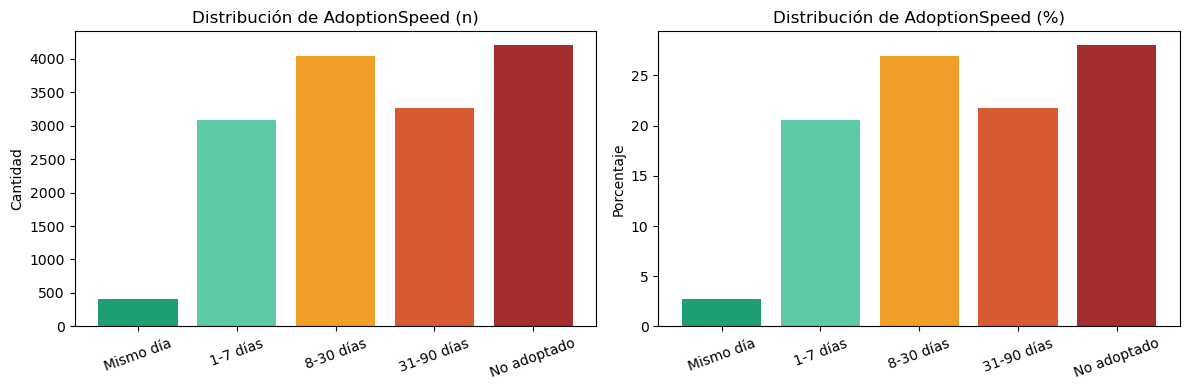

[OK] Figura guardada: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs\eda_01_adoption_speed.png


'La variable objetivo AdoptionSpeed presenta una distribución marcadamente desbalanceada entre sus cinco clases. La clase dominante es la 4 (no adoptado en 90 días) con el 28% de los casos, seguida de cerca por la clase 2 (adoptado entre 8 y 30 días) con el 26.9%. Las clases 1 y 3 concentran aproximadamente el 20% cada una, mientras que la clase 0 (adoptado el mismo día) representa apenas el 2.7% del total, con solo 410 registros sobre 14.993.\nEl ratio de desbalance entre la clase mayoritaria y la minoritaria es de 10.2x, lo que tiene implicancias directas sobre la estrategia de modelado. Un modelo que ignorara este desbalance tendería a clasificar las observaciones hacia las clases más frecuentes, subestimando sistemáticamente la clase 0. Para mitigar este efecto se aplican dos medidas: el uso de particiones estratificadas (stratify=y) al dividir los datos, que garantiza que la proporción de cada clase se preserve tanto en el conjunto de entrenamiento como en el de validación, y la a

In [ ]:
# =============================================================================
#  ETAPA 2 · EDA — VARIABLE OBJETIVO (AdoptionSpeed)
# =============================================================================

#  La variable objetivo AdoptionSpeed indica la velocidad con la que cada
#  mascota fue adoptada, codificada en cinco clases ordinales: 0 (mismo
#  día), 1 (dentro de la primera semana), 2 (dentro del primer mes), 3
#  (dentro de los primeros tres meses) y 4 (no adoptada en 90 días).
#  Se analiza la distribución de frecuencias entre clases para detectar
#  desbalance, se cuantifica el ratio entre la clase mayoritaria y la
#  minoritaria, y se evalúan las implicancias para la elección de la
#  métrica de evaluación y la estrategia de partición de los datos.
#
# =============================================================================
print("\n" + "="*70)
print("  ETAPA 2 · EDA — VARIABLE OBJETIVO (AdoptionSpeed)")
print("="*70)


# ── 2.1 Distribución de clases ─────────────────────────────────────────────
counts = df_eda['AdoptionSpeed'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100
labels_speed = {0:"Mismo día", 1:"1-7 días", 2:"8-30 días",
                3:"31-90 días", 4:"No adoptado"}

print("\n--- Conteo por clase ---")
for clase in counts.index:
    print(f"  Clase {clase} ({labels_speed[clase]}): "
          f"{counts[clase]:5d} mascotas  ({pcts[clase]:.1f}%)")

ratio = counts.max() / counts.min()
print(f"\n[ALERTA] Ratio de desbalance: {ratio:.1f}x  "
      f"(clase {counts.idxmax()} vs clase {counts.idxmin()})")
print("[INFO] Implicancia: usar stratify=y en splits y QWK como métrica.")

# ── 2.2 Gráfico ────────────────────────────────────────────────────────────
colors = ['#1D9E75','#5DCAA5','#EF9F27','#D85A30','#A32D2D']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Distribución de AdoptionSpeed (n)')
axes[0].set_xticks([0,1,2,3,4])
axes[0].set_xticklabels([labels_speed[i] for i in range(5)], rotation=20)
axes[0].set_ylabel('Cantidad')

axes[1].bar(pcts.index, pcts.values, color=colors)
axes[1].set_title('Distribución de AdoptionSpeed (%)')
axes[1].set_xticks([0,1,2,3,4])
axes[1].set_xticklabels([labels_speed[i] for i in range(5)], rotation=20)
axes[1].set_ylabel('Porcentaje')

plt.tight_layout()
save_fig('eda_01_adoption_speed.png')

"""La variable objetivo AdoptionSpeed presenta una distribución marcadamente desbalanceada entre sus cinco clases. La clase dominante es la 4 (no adoptado en 90 días) con el 28% de los casos, seguida de cerca por la clase 2 (adoptado entre 8 y 30 días) con el 26.9%. Las clases 1 y 3 concentran aproximadamente el 20% cada una, mientras que la clase 0 (adoptado el mismo día) representa apenas el 2.7% del total, con solo 410 registros sobre 14.993.
El ratio de desbalance entre la clase mayoritaria y la minoritaria es de 10.2x, lo que tiene implicancias directas sobre la estrategia de modelado. Un modelo que ignorara este desbalance tendería a clasificar las observaciones hacia las clases más frecuentes, subestimando sistemáticamente la clase 0. Para mitigar este efecto se aplican dos medidas: el uso de particiones estratificadas (stratify=y) al dividir los datos, que garantiza que la proporción de cada clase se preserve tanto en el conjunto de entrenamiento como en el de validación, y la adopción del Quadratic Weighted Kappa (QWK) como métrica de evaluación principal, que penaliza los errores de forma proporcional a su distancia ordinal y resulta más informativa que la accuracy ante distribuciones desbalanceadas.
Vale notar que el desbalance, si bien significativo, no es extremo en términos absolutos: las clases 1, 2, 3 y 4 tienen representación razonable. El problema se concentra exclusivamente en la clase 0, cuya escasa presencia exige atención particular durante la validación cruzada para asegurar que al menos algunos registros de esta clase estén presentes en cada fold de validación.
"""


## EDA — Etapa 3: Variables Numéricas



  ETAPA 3 · EDA — VARIABLES NUMÉRICAS

--- Estadísticas descriptivas ---
            Age       Fee  PhotoAmt  VideoAmt  Quantity
count  14993.00  14993.00  14993.00  14993.00  14993.00
mean      10.45     21.26      3.89      0.06      1.58
std       18.16     78.41      3.49      0.35      1.47
min        0.00      0.00      0.00      0.00      1.00
25%        2.00      0.00      2.00      0.00      1.00
50%        3.00      0.00      3.00      0.00      1.00
75%       12.00      0.00      5.00      0.00      1.00
max      255.00   3000.00     30.00      8.00     20.00

--- Outliers (1.5 × IQR) ---
  Age         : 1501 outliers  (mediana=3, max=255)
  Fee         : 2330 outliers  (mediana=0, max=3000)
  PhotoAmt    :  922 outliers  (mediana=3, max=30)
  VideoAmt    :  574 outliers  (mediana=0, max=8)
  Quantity    : 3428 outliers  (mediana=1, max=20)


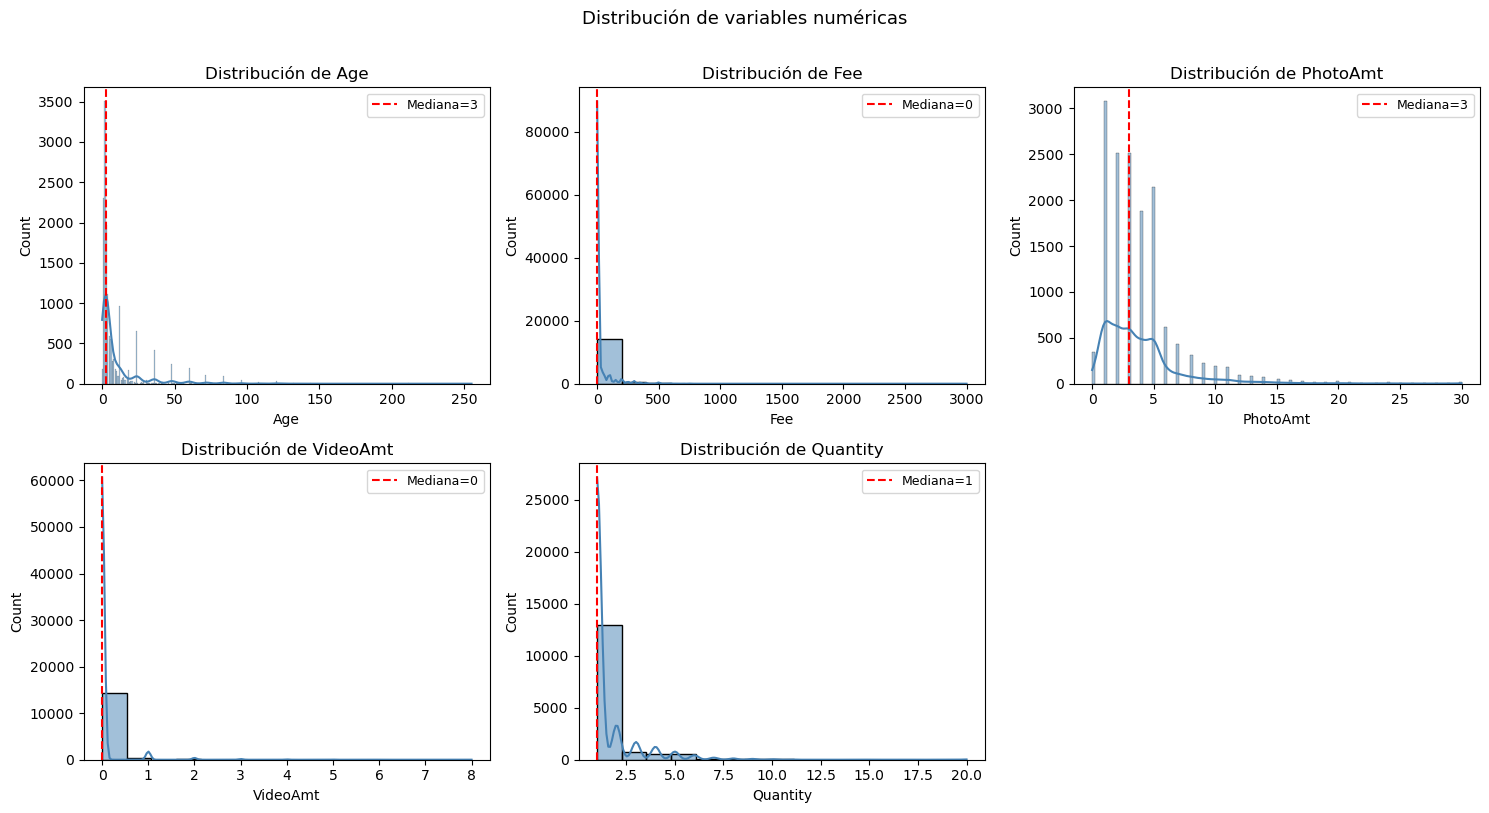

[OK] Figura guardada: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs\eda_02_numericas_histogramas.png


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6936\2585601839.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y=col, data=df_eda,
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6936\2585601839.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y=col, data=df_eda,
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6936\2585601839.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y=col, data=df_eda,


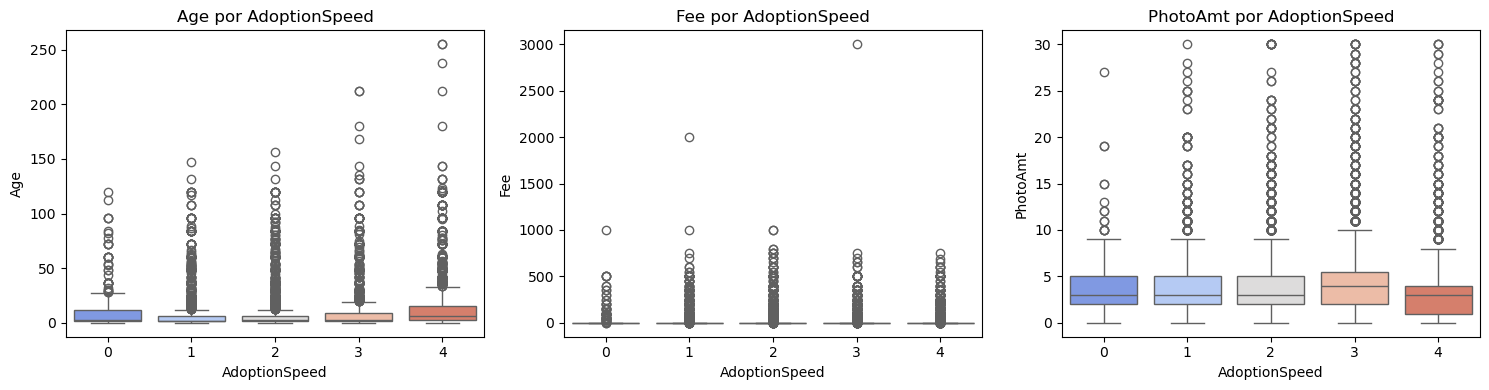

[OK] Figura guardada: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs\eda_03_numericas_vs_target.png


'**Age por AdoptionSpeed**\nLa distribución de edad es muy similar entre las clases 0, 1 y 2, con medianas bajas y cajas compactas en el rango de 0 a 10 meses. La diferencia más notoria aparece en las clases 3 y 4, donde la caja se amplía y la mediana sube levemente, sugiriendo que las mascotas de mayor edad tienden a tardar más en ser adoptadas o directamente no son adoptadas. En todas las clases hay una cantidad considerable de outliers por encima de 50 meses, algunos llegando a 250, distribuidos de forma bastante pareja entre clases — lo que indica que los valores extremos no son exclusivos de ninguna velocidad de adopción en particular. La señal predictiva de Age existe pero es moderada.\n\n**Fee por AdoptionSpeed**\nEs la variable con menor poder discriminativo de las tres. En todas las clases la mediana es 0 y la caja está completamente aplastada contra el eje, lo que confirma que más del 75% de los anuncios son gratuitos en cada clase. Los outliers de tarifas altas (hasta 3000 M

In [ ]:
import seaborn as sns

# =============================================================================
#  ETAPA 3 · EDA — VARIABLES NUMÉRICAS
# =============================================================================
#  Se analizan las cinco variables de naturaleza continua o de conteo
#  presentes en el dataset: Age (edad de la mascota en meses), Fee (tarifa
#  de adopción en ringgit malayo), PhotoAmt (cantidad de fotos en el
#  anuncio), VideoAmt (cantidad de videos) y Quantity (número de mascotas
#  incluidas en el anuncio). Para cada variable se calculan estadísticas
#  descriptivas, se detectan valores atípicos mediante el criterio del
#  rango intercuartílico (IQR), y se visualiza su distribución mediante
#  histogramas con estimación de densidad. Adicionalmente, se construyen
#  diagramas de caja segmentados por clase de AdoptionSpeed para evaluar
#  la relación de cada variable con el target.
#
# =============================================================================
print("\n" + "="*70)
print("  ETAPA 3 · EDA — VARIABLES NUMÉRICAS")
print("="*70)

NUM_VARS = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt', 'Quantity']

print("\n--- Estadísticas descriptivas ---")
print(df_eda[NUM_VARS].describe().round(2).to_string())

# ── 3.1 Outliers con IQR ──────────────────────────────────────────────────
print("\n--- Outliers (1.5 × IQR) ---")
for col in NUM_VARS:
    Q1, Q3 = df_eda[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    n_out  = ((df_eda[col] < Q1 - 1.5*IQR) |
               (df_eda[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:12s}: {n_out:4d} outliers  "
          f"(mediana={df_eda[col].median():.0f}, max={df_eda[col].max():.0f})")

"""Age — 1.501 valores atípicos sobre un rango que va de 0 a 255 meses. Con una mediana de 3 meses, cualquier mascota por encima de aproximadamente 15–18 meses ya cae fuera del rango intercuartílico. Los outliers no son necesariamente errores: una mascota adulta de 5 años es biológicamente válida, pero estadísticamente infrecuente en este dataset dominado por crías. Los casos extremos como 255 meses (21 años) sí merecen revisión, ya que podrían ser errores de carga ---VEEERRRRR---.

Fee — 2.330 outliers, la segunda cantidad más alta. Con mediana 0 y más del 75% de los valores en 0, cualquier anuncio con tarifa mayor a 0 es técnicamente un outlier según el criterio IQR. Esto no refleja anomalías reales sino la naturaleza bimodal de la variable: la mayoría absoluta es gratuita y una minoría tiene tarifas que van hasta 3.000 MYR. El criterio IQR no es apropiado para variables con tanta masa en cero; la variable debe tratarse como binaria (is_free) o aplicar una transformación logarítmica si se quiere usar el valor continuo.(---VERRR TAMBIEN---)

PhotoAmt — 922 outliers con mediana 3 y máximo 30. El rango intercuartílico es estrecho (la mayoría de anuncios tiene entre 2 y 5 fotos), por lo que valores a partir de 8–9 fotos ya califican como outliers. En este caso los outliers son informativos: un anuncio con 20 fotos refleja mayor dedicación del rescatista y potencialmente mayor atractivo para adoptantes.

VideoAmt — 574 outliers con mediana 0 y máximo 8. Al igual que Fee, la concentración masiva en 0 hace que cualquier anuncio con al menos un video sea un outlier estadístico. Más del 90% de los anuncios no tiene videos, por lo que la variable prácticamente no aporta información continua. Se justifica convertirla en una variable binaria has_video.

Quantity — 3.428 outliers, la cantidad más alta de todas las variables. Con mediana 1 y el grueso de los anuncios para una sola mascota, cualquier anuncio con 2 o más mascotas puede caer fuera del IQR. El máximo de 20 representa anuncios de adopción grupal, que son casos legítimos pero estadísticamente atípicos. Es la variable con mayor proporción de outliers en términos relativos, lo que refleja la alta concentración del dataset en anuncios individuales.
"""

# ── 3.2 Histogramas ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(NUM_VARS):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].axvline(df_eda[col].median(), color='red', linestyle='--',
                    label=f'Mediana={df_eda[col].median():.0f}')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].legend(fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Distribución de variables numéricas', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('eda_02_numericas_histogramas.png')

"""Age

Distribución con sesgo pronunciado a la derecha y pico muy marcado en los primeros meses de vida. La masa principal se concentra entre 0 y 10 meses, con la mediana en 3 meses. A partir de los 12 meses la frecuencia cae abruptamente y la cola se extiende hasta los 255 meses de forma casi plana, con algunas acumulaciones visibles alrededor de los 12, 24 y 36 meses que probablemente corresponden a redondeos al año más cercano al momento de registrar la edad. La curva de densidad refleja con claridad la asimetría: la media está muy por encima de la mediana debido al efecto de los valores extremos. Esta distribución justifica aplicar una transformación logarítmica si se utilizan modelos sensibles a la escala, aunque para LightGBM no es estrictamente necesario.

Fee

La distribución es marcadamente bimodal, aunque visualmente parece unimodal por la diferencia de escala entre los dos grupos. La barra del valor 0 supera los 80.000 conteos — lo que refleja múltiples bins del histograma sumados — mientras que el resto de los valores, agrupados en el rango 1–3.000 MYR, forman una barra secundaria de aproximadamente 12.000 registros. La mediana en 0 confirma que la mayoría absoluta de los anuncios es gratuita. La cola derecha llega hasta 3.000 MYR pero con frecuencias muy bajas. Esta forma de distribución hace que el valor continuo sea poco informativo para el modelo y refuerza la decisión de crear la variable binaria is_free.

PhotoAmt

Es la distribución más interesante del conjunto. Tiene forma aproximadamente unimodal con pico en 1–2 fotos, mediana en 3 y una cola que se extiende hasta 30. A diferencia de Age y Fee, la dispersión es más equilibrada: hay masa significativa entre 1 y 8 fotos, y la caída hacia los valores altos es gradual. Se observan algunos picos secundarios alrededor de 4–5 fotos que sugieren valores preferidos por los rescatistas al subir fotos. La distribución no es extrema y la variable es directamente utilizable en el modelo sin transformaciones. Su forma confirma que hay variabilidad suficiente para que sea un predictor útil.

VideoAmt

Distribución prácticamente degenerada: una barra dominante en 0 con más de 60.000 conteos y una barra residual en 1 con aproximadamente 14.000. Los valores entre 2 y 8 son casi imperceptibles en el gráfico. La mediana en 0 y la ausencia visual de variabilidad confirman que esta variable no aporta información continua al modelo. Su único valor predictivo reside en distinguir si el anuncio tiene o no tiene al menos un video, lo que se captura completamente con la variable binaria has_video.

Quantity

Distribución similar a VideoAmt en su forma pero con una cola más pronunciada. El valor 1 concentra la amplia mayoría de los registros, con una barra que supera los 25.000 conteos. El valor 2 tiene una presencia notoria de aproximadamente 13.000 registros, lo que indica que los anuncios de dos mascotas son relativamente frecuentes. A partir de 3 la frecuencia cae de forma pronunciada y la cola se extiende hasta 20, con muy pocos casos. La mediana en 1 y la forma del histograma reflejan que los anuncios de adopción múltiple son la excepción. La variable es utilizable en su forma continua, aunque el grueso de su información se concentra en los primeros valores enteros.



"""

# ── 3.3 Boxplots vs AdoptionSpeed ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Fee', 'PhotoAmt']):
    sns.boxplot(x='AdoptionSpeed', y=col, data=df_eda,
                ax=ax, palette='coolwarm')
    ax.set_title(f'{col} por AdoptionSpeed')
plt.tight_layout()
save_fig('eda_03_numericas_vs_target.png')

"""**Age por AdoptionSpeed**
La distribución de edad es muy similar entre las clases 0, 1 y 2, con medianas bajas y cajas compactas en el rango de 0 a 10 meses. La diferencia más notoria aparece en las clases 3 y 4, donde la caja se amplía y la mediana sube levemente, sugiriendo que las mascotas de mayor edad tienden a tardar más en ser adoptadas o directamente no son adoptadas. En todas las clases hay una cantidad considerable de outliers por encima de 50 meses, algunos llegando a 250, distribuidos de forma bastante pareja entre clases — lo que indica que los valores extremos no son exclusivos de ninguna velocidad de adopción en particular. La señal predictiva de Age existe pero es moderada.

**Fee por AdoptionSpeed**
Es la variable con menor poder discriminativo de las tres. En todas las clases la mediana es 0 y la caja está completamente aplastada contra el eje, lo que confirma que más del 75% de los anuncios son gratuitos en cada clase. Los outliers de tarifas altas (hasta 3000 MYR) aparecen en todas las clases sin un patrón claro. Esto refuerza la decisión de transformar Fee en una variable binaria is_free en lugar de usar el valor continuo: la distinción relevante es gratuito vs. no gratuito, no el monto exacto de la tarifa.

**PhotoAmt por AdoptionSpeed**
Es la variable con la señal más legible de las tres. Las clases 0 y 1 (adopciones rápidas) tienen cajas más altas y medianas visiblemente mayores que las clases 3 y 4 (lentas o no adoptadas). La clase 4 en particular muestra la caja más comprimida y baja, con mediana cercana a 2 fotos. Esto confirma la correlación negativa entre PhotoAmt y AdoptionSpeed que anticipaba el EDA: los anuncios con más fotos tienden a generar adopciones más rápidas. La presencia de outliers en 25–30 fotos en todas las clases sugiere que una cantidad excesiva de fotos no garantiza adopción rápida, pero la ausencia de fotos sí se asocia con adopciones más lentas.
"""


## EDA — Etapa 4: Variables Categóricas y Pareto de Breed1



  ETAPA 4 · EDA — VARIABLES CATEGÓRICAS

--- Cardinalidad (valores únicos) ---
  Breed1         :  176 valores únicos ⚠ ALTA CARDINALIDAD
  Breed2         :  135 valores únicos ⚠ ALTA CARDINALIDAD
  State          :   14 valores únicos
  Color1         :    7 valores únicos
  MaturitySize   :    4 valores únicos
  Gender         :    3 valores únicos
  FurLength      :    3 valores únicos
  Vaccinated     :    3 valores únicos
  Dewormed       :    3 valores únicos
  Sterilized     :    3 valores únicos
  Health         :    3 valores únicos
  Type           :    2 valores únicos


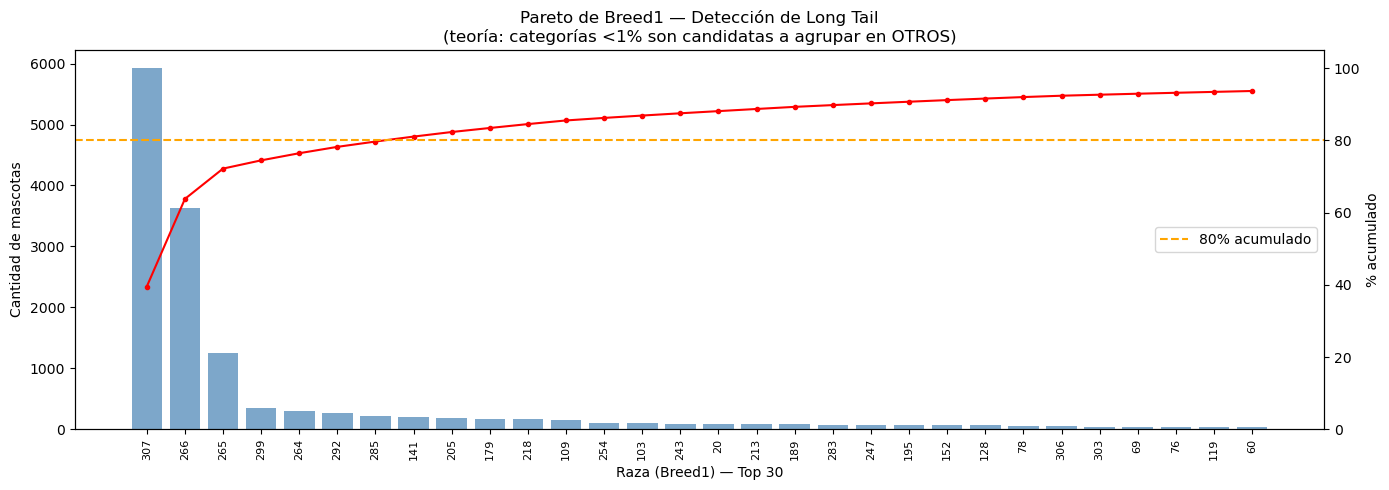

[OK] Figura guardada: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs\eda_04_pareto_breed.png

[INFO] Razas con menos del 1.0% de registros: 164 razas (14.5% del total)
[INFO] Estrategia: frequency encoding + target encoding con smoothing
[INFO] Alternativa: agrupar las raras en categoría OTROS

[IMPORTANTE] Vaccinated, Dewormed, Sterilized:
  Valor 1=Sí | 2=No | 3=No sé
  NO encodear como ordinal (el 3 no es 'más que 2').
  Estrategia: pasar como categórica a LightGBM o one-hot.


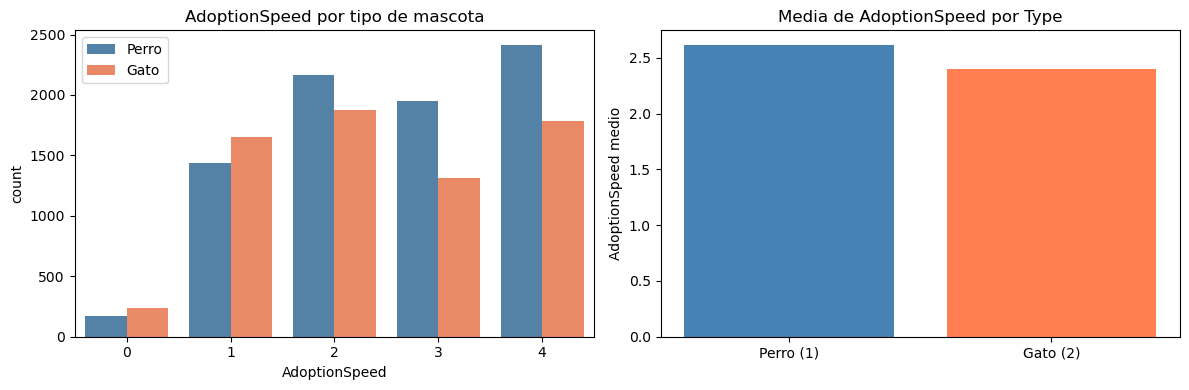

[OK] Figura guardada: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs\eda_05_categoricas.png

--- Media de AdoptionSpeed por categoría ---

  Type: {1: 2.615, 2: 2.4}

  Gender: {1: 2.419, 2: 2.57, 3: 2.586}

  Vaccinated: {1: 2.67, 2: 2.362, 3: 2.629}

  Health: {1: 2.51, 2: 2.659, 3: 3.029}

  Sterilized: {1: 2.902, 2: 2.362, 3: 2.716}

  FurLength: {1: 2.585, 2: 2.47, 3: 2.08}


'**Type**\nLos gatos se adoptan en promedio algo más rápido que los perros en este dataset. La diferencia es modesta pero consistente.\n\n**Gender**\nLos machos (1) se adoptan más rápido que las hembras (2), con medias de 2.419 y 2.570 respectivamente. Los grupos mixtos (3) tienen una media similar a las hembras (2.586). La diferencia entre machos y hembras es pequeña pero presente, y el valor 3 confirma que no tiene sentido tratar Gender como ordinal: machos y grupos mixtos tienen medias parecidas mientras que hembras quedan en el medio.\n\n**Vaccinated**\nLas mascotas vacunadas (1) tienen media 2.67, las no vacunadas (2) tienen 2.362 y las de estado desconocido (3) tienen 2.629. El resultado más llamativo es que las no vacunadas se adoptan más rápido que las vacunadas, lo cual parece contraintuitivo. Una explicación posible es que muchas mascotas muy jóvenes aún no están vacunadas y, como vimos, la juventud es un factor asociado a adopción rápida. También refuerza por qué el valor 3 

In [ ]:
# =============================================================================
#  ETAPA 4 · EDA — VARIABLES CATEGÓRICAS + PARETO DE CARDINALIDAD
# =============================================================================
#
#  Se analizan las doce variables de naturaleza categórica del dataset.
#  El foco principal es la detección y tratamiento del problema de alta
#  cardinalidad en Breed1 (307 razas posibles): se construye un gráfico
#  de Pareto que muestra la concentración de registros en pocas razas y
#  la larga cola de razas con muy poca representación, lo que fundamenta
#  la elección de estrategias de encoding específicas. Se documenta además
#  la codificación particular de Vaccinated, Dewormed y Sterilized, donde
#  el valor 3 representa incertidumbre ("No sé") y no debe interpretarse
#  como una categoría ordinal. Finalmente, se compara la distribución de
#  AdoptionSpeed entre perros y gatos, y se calcula la media del target
#  por categoría para las variables de baja cardinalidad.
#
# =============================================================================
print("\n" + "="*70)
print("  ETAPA 4 · EDA — VARIABLES CATEGÓRICAS")
print("="*70)

CAT_VARS = ['Type','Gender','Color1','MaturitySize','FurLength',
            'Vaccinated','Dewormed','Sterilized','Health','Breed1','Breed2','State']



# ── 4.1 Cardinalidad ──────────────────────────────────────────────────────
print("\n--- Cardinalidad (valores únicos) ---")
for col, n in df_eda[CAT_VARS].nunique().sort_values(ascending=False).items():
    alerta = " ⚠ ALTA CARDINALIDAD" if n > 50 else ""
    print(f"  {col:15s}: {n:4d} valores únicos{alerta}")

"""**Breed1 y Breed2 — Alta cardinalidad**
Breed1 presenta 176 valores únicos y Breed2 135, ambos marcados como variables de alta cardinalidad. Son las únicas dos variables del dataset que superan el umbral de 50 categorías, lo que las distingue cualitativamente del resto. Una codificación one-hot directa generaría cientos de columnas adicionales, introduciría alta dimensionalidad y produciría columnas con muy pocos registros positivos para las razas infrecuentes. El análisis de Pareto sobre Breed1 confirmó que la distribución sigue una ley de potencia: pocas razas concentran la mayoría de los registros y una larga cola de razas raras tiene representación mínima. Para ambas variables se adopta una estrategia combinada de frequency encoding y target encoding con smoothing calculado dentro de cada fold de validación cruzada, lo que permite capturar la información de raza sin incurrir en data leakage ni en la explosión dimensional del one-hot encoding.

**State — Cardinalidad moderada**
Con 14 valores únicos correspondientes a los estados de Malasia, State tiene una cardinalidad manejable. Sin embargo, al tratarse de una variable geográfica con potencial correlación con el target (distintos estados pueden tener distintas tasas de adopción), se aplica target encoding con smoothing en lugar de one-hot, que con 14 categorías sería viable pero menos informativo que una representación basada en el comportamiento histórico de adopción por estado.

**Color1 — Baja cardinalidad**
Siete valores únicos representan los colores principales del pelaje. Es una variable directamente utilizable por LightGBM sin transformación adicional. El color puede tener cierta correlación con la raza o el tipo de mascota, pero su poder predictivo individual es probablemente bajo.

**MaturitySize — Cuatro categorías ordenadas**
Representa el tamaño adulto esperado de la mascota en cuatro niveles (pequeño, mediano, grande, extra grande). Al tener un orden natural genuino puede tratarse como variable ordinal y pasarse directamente al modelo con su codificación numérica original.

**Gender, Sterilized, FurLength, Vaccinated, Dewormed, Health — Tres categorías**
Este grupo de variables comparte la misma cardinalidad de tres valores, pero con semánticas distintas que condicionan su tratamiento. FurLength y MaturitySize tienen un orden natural claro y pueden usarse como ordinales. Health también es ordenada (1=sano, 2=lesión menor, 3=lesión grave) y su codificación numérica es directamente interpretable. En cambio, Vaccinated, Dewormed y Sterilized tienen una categoría especial: el valor 3 significa "No sé" y no representa un grado mayor que el 2. Tratarlas como ordinales sería incorrecto; se pasan al modelo como categóricas nominales para que LightGBM las maneje sin asumir orden entre sus valores.

**Type — Variable binaria**
Con solo dos valores posibles (1=perro, 2=gato), Type es la variable de menor cardinalidad del dataset. Es directamente utilizable sin ninguna transformación, o alternativamente puede convertirse en una variable binaria 0/1 mediante la feature derivada is_dog.
"""

# ── 4.2 Pareto de Breed1 — teoría: detectar long tail ────────────────────
# La teoría indica usar un gráfico de Pareto para identificar
# categorías con menos del 1% de registros (candidatas a agrupar en OTROS)
breed_counts = df_eda['Breed1'].value_counts()
breed_pct    = breed_counts / len(df_eda) * 100
breed_cumsum = breed_pct.cumsum()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Barras: top 30 razas más frecuentes
top30 = breed_counts.head(30)
ax1.bar(range(len(top30)), top30.values, color='steelblue', alpha=0.7)
ax1.set_xlabel('Raza (Breed1) — Top 30')
ax1.set_ylabel('Cantidad de mascotas')
ax1.set_xticks(range(len(top30)))
ax1.set_xticklabels(top30.index, rotation=90, fontsize=8)

# Línea acumulada
cumsum_top30 = breed_pct.head(30).cumsum()
ax2.plot(range(len(top30)), cumsum_top30.values, color='red',
         marker='o', markersize=3, linewidth=1.5)
ax2.axhline(80, color='orange', linestyle='--', label='80% acumulado')
ax2.set_ylabel('% acumulado')
ax2.set_ylim(0, 105)
ax2.legend(loc='center right')

plt.title('Pareto de Breed1 — Detección de Long Tail\n'
          '(teoría: categorías <1% son candidatas a agrupar en OTROS)')
plt.tight_layout()
save_fig('eda_04_pareto_breed.png')

# Categorías con menos del 1% de registros
umbral_pct = 1.0
raras = breed_pct[breed_pct < umbral_pct]
print(f"\n[INFO] Razas con menos del {umbral_pct}% de registros: {len(raras)} razas "
      f"({raras.sum():.1f}% del total)")
print("[INFO] Estrategia: frequency encoding + target encoding con smoothing")
print("[INFO] Alternativa: agrupar las raras en categoría OTROS")

"""Las tres primeras barras (307, 266 y 265) son enormes comparadas con el resto. La 307 sola tiene casi 6.000 mascotas — eso es el código para mestizo. Las barras caen muy rápido y desde la cuarta en adelante ya son pequeñas y bastante parejas entre sí.
La línea roja cruza el 80% recién alrededor de la barra número 8 o 9. Eso quiere decir que solo 8 o 9 razas concentran el 80% de todas las mascotas del dataset. El otro 20% está repartido entre más de 160 razas.
"""

# ── 4.3 Advertencia Vaccinated / Dewormed / Sterilized ────────────────────
print("\n[IMPORTANTE] Vaccinated, Dewormed, Sterilized:")
print("  Valor 1=Sí | 2=No | 3=No sé")
print("  NO encodear como ordinal (el 3 no es 'más que 2').")
print("  Estrategia: pasar como categórica a LightGBM o one-hot.")

# ── 4.4 AdoptionSpeed por Type (perros vs gatos) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='AdoptionSpeed', hue='Type', data=df_eda,
              palette={1:'steelblue', 2:'coral'}, ax=axes[0])
axes[0].set_title('AdoptionSpeed por tipo de mascota')
axes[0].legend(['Perro', 'Gato'])

mean_by_type = df_eda.groupby('Type')['AdoptionSpeed'].mean()
axes[1].bar(['Perro (1)', 'Gato (2)'], mean_by_type.values,
            color=['steelblue', 'coral'])
axes[1].set_title('Media de AdoptionSpeed por Type')
axes[1].set_ylabel('AdoptionSpeed medio')
plt.tight_layout()
save_fig('eda_05_categoricas.png')

# Media de AdoptionSpeed por variable categórica de baja cardinalidad
print("\n--- Media de AdoptionSpeed por categoría ---")
for col in ['Type','Gender','Vaccinated','Health','Sterilized','FurLength']:
    means = df_eda.groupby(col)['AdoptionSpeed'].mean().round(3)
    print(f"\n  {col}: {means.to_dict()}")

"""**Type**
Los gatos se adoptan en promedio algo más rápido que los perros en este dataset. La diferencia es modesta pero consistente.

**Gender**
Los machos (1) se adoptan más rápido que las hembras (2), con medias de 2.419 y 2.570 respectivamente. Los grupos mixtos (3) tienen una media similar a las hembras (2.586). La diferencia entre machos y hembras es pequeña pero presente, y el valor 3 confirma que no tiene sentido tratar Gender como ordinal: machos y grupos mixtos tienen medias parecidas mientras que hembras quedan en el medio.

**Vaccinated**
Las mascotas vacunadas (1) tienen media 2.67, las no vacunadas (2) tienen 2.362 y las de estado desconocido (3) tienen 2.629. El resultado más llamativo es que las no vacunadas se adoptan más rápido que las vacunadas, lo cual parece contraintuitivo. Una explicación posible es que muchas mascotas muy jóvenes aún no están vacunadas y, como vimos, la juventud es un factor asociado a adopción rápida. También refuerza por qué el valor 3 no puede tratarse como ordinal: su media (2.629) es casi idéntica a la de las vacunadas (2.67) y muy distinta de las no vacunadas (2.362).

**Health**
Es la variable con el patrón más claro y esperable de todo el análisis. Las mascotas sanas (1) tienen media 2.51, las de lesión menor (2) suben a 2.659 y las de lesión grave (3) llegan a 3.029. La relación es perfectamente monotónica: a peor estado de salud, mayor AdoptionSpeed, es decir, adopción más lenta. Esta es la única variable categórica que justifica plenamente un tratamiento ordinal, ya que sus categorías tienen tanto un orden natural como un efecto consistente sobre el target.

**Sterilized**
Las mascotas esterilizadas (1) tienen la media más alta del grupo (2.902), las no esterilizadas (2) la más baja (2.362) y las de estado desconocido (3) quedan en 2.716. Las mascotas esterilizadas se adoptan más lento, lo que nuevamente parece contraintuitivo pero puede explicarse por correlación con la edad: las mascotas mayores tienen más probabilidad de estar esterilizadas y, como se vio, la edad se asocia con adopción más lenta. El valor 3 queda entre los otros dos, confirmando que no tiene relación ordinal con 1 y 2.

**FurLength**
El patrón es inverso al esperado: las mascotas de pelo largo (3) tienen la media más baja (2.08), indicando adopciones más rápidas, mientras que las de pelo corto (1) tienen la más alta (2.585). Las de pelo medio (2) quedan en 2.470. Aunque FurLength tiene un orden natural, su efecto sobre el target no sigue ese orden de forma simple. El pelo largo puede estar correlacionado con razas específicas o tipos de mascotas con mayor demanda de adopción. Es una variable que aporta información pero requiere que el modelo aprenda su relación de forma no lineal.
"""


## EDA — Etapa 5: Valores Nulos y Datos Faltantes


In [ ]:
# =============================================================================
#  ETAPA 5 · EDA — VALORES NULOS Y DATOS FALTANTES
# =============================================================================
#
#  El CSV principal no presenta valores nulos en el sentido clásico, pero
#  contiene datos faltantes disfrazados que requieren tratamiento explícito:
#  mascotas sin nombre registradas como "No Name" y descripciones con
#  contenido vacío. Un caso de mayor relevancia es la ausencia de archivos
#  JSON de sentimiento o de metadata de imagen para un subconjunto de
#  anuncios. Estos faltantes no son aleatorios (MNAR/MAR): la ausencia de
#  un JSON de sentimiento se correlaciona con la ausencia de descripción,
#  y la ausencia de metadata de imagen con la ausencia de fotos. En ambos
#  casos, el faltante en sí mismo constituye información predictiva y se
#  incorporará al modelo mediante variables indicadoras (flags).
#
# =============================================================================
print("\n" + "="*70)
print("  ETAPA 5 · EDA — VALORES NULOS Y DATOS FALTANTES")
print("="*70)

# ── 5.1 Nulos clásicos ────────────────────────────────────────────────────
nulos = df_eda.isnull().sum()
nulos = nulos[nulos > 0]
print("\n--- Nulos clásicos en el CSV ---")
if len(nulos) == 0:
    print("  [OK] Sin NaN en el CSV principal.")
else:
    print(nulos.to_string())

# ── 5.2 Nulos disfrazados ──────────────────────────────────────────────────
sin_nombre  = (df_eda['Name'] == 'No Name').sum()
desc_vacia  = (df_eda['Description'].fillna('').str.strip() == '').sum()
print(f"\n--- Nulos disfrazados ---")
print(f"  Sin nombre ('No Name'): {sin_nombre:,} ({sin_nombre/len(df_eda)*100:.1f}%)")
print(f"  Descripción vacía:      {desc_vacia:,}  ({desc_vacia/len(df_eda)*100:.1f}%)")
print(f"  Breed2 == 0 (pura raza): "
      f"{(df_eda['Breed2']==0).sum():,} ({(df_eda['Breed2']==0).mean()*100:.1f}%)  "
      f"← válido, no es nulo")

# ── 5.3 JSONs externos faltantes ──────────────────────────────────────────
def count_missing_json(pet_ids, folder, suffix='.json'):
    return sum(1 for pid in pet_ids
               if not glob.glob(os.path.join(folder, f'{pid}*{suffix}')))

print(f"\n--- JSONs externos faltantes ---")
if os.path.exists(SENTIMENT_DIR):
    n_sent = count_missing_json(df_eda['PetID'], SENTIMENT_DIR)
    print(f"  Sin sentiment JSON: {n_sent:,} ({n_sent/len(df_eda)*100:.1f}%)")
else:
    print(f"  [AVISO] '{SENTIMENT_DIR}' no encontrada.")

if os.path.exists(METADATA_DIR):
    n_meta = count_missing_json(df_eda['PetID'], METADATA_DIR)
    print(f"  Sin image metadata: {n_meta:,} ({n_meta/len(df_eda)*100:.1f}%)")
else:
    print(f"  [AVISO] '{METADATA_DIR}' no encontrada.")

print("\n[ESTRATEGIA]")
print("  → has_sentiment y has_image_meta como features explícitas")
print("  → El faltante NO es aleatorio (MAR/MNAR): aporta información")
print("  → LightGBM maneja NaN nativo, pero los flags son señal adicional")



  ETAPA 5 · EDA — VALORES NULOS Y DATOS FALTANTES

--- Nulos clásicos en el CSV ---
Name           1265
Description      13

--- Nulos disfrazados ---
  Sin nombre ('No Name'): 54 (0.4%)
  Descripción vacía:      13  (0.1%)
  Breed2 == 0 (pura raza): 10,762 (71.8%)  ← válido, no es nulo

--- JSONs externos faltantes ---
  [AVISO] 'C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\train_sentiment' no encontrada.
  [AVISO] 'C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\train_metadata' no encontrada.

[ESTRATEGIA]
  → has_sentiment y has_image_meta como features explícitas
  → El faltante NO es aleatorio (MAR/MNAR): aporta información
  → LightGBM maneja NaN nativo, pero los flags son señal adicional


## EDA — Etapa 6: Correlaciones y Cierre del EDA



  ETAPA 6 · EDA — CORRELACIONES Y CIERRE DEL EDA

--- Correlación de Spearman con AdoptionSpeed ---
  Age         : r=+0.210  p=0.0000  ✓
  Fee         : r=+0.018  p=0.0237  ✓
  PhotoAmt    : r=-0.062  p=0.0000  ✓
  VideoAmt    : r=-0.011  p=0.1613  ✗
  Quantity    : r=+0.053  p=0.0000  ✓


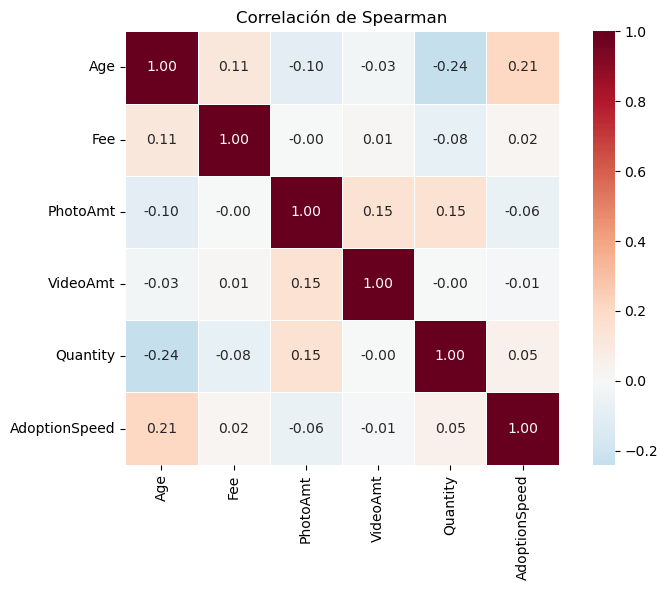

[OK] Figura guardada: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs\eda_06_correlaciones.png

--- Multicolinealidad entre features (|r| > 0.6) ---
  [OK] Sin multicolinealidad severa.

[RESUMEN EDA — puntos clave para el modelo]
  ✓ AdoptionSpeed desbalanceada (clase 0 = 3%) → stratify + QWK
  ✓ PhotoAmt: predictor más fuerte
  ✓ Age: sesgada, outliers extremos
  ✓ Fee: bimodal → crear is_free
  ✓ Breed1: 307 categorías → alta cardinalidad, aplicar teoría
  ✓ Vaccinated/Dewormed/Sterilized: valor 3 = 'No sé', no ordinal
  ✓ JSONs faltantes: información implícita → crear flags


'Ningún par de variables numéricas supera una correlación de 0.6 en valor absoluto. Esto confirma que las variables predictoras aportan información distinta entre sí y que no es necesario eliminar ninguna por redundancia. El modelo puede utilizar todas las variables numéricas sin riesgo de que dos de ellas estén midiendo esencialmente lo mismo.\n\n'

In [ ]:
from scipy import stats

# =============================================================================
#  ETAPA 6 · EDA — CORRELACIONES Y CIERRE
# =============================================================================
#  En esta fase cuantificamos la relación lineal entre cada variable numérica y la
#  variable objetivo mediante el coeficiente de correlación de Spearman,
#  preferido sobre Pearson dado el carácter ordinal de AdoptionSpeed. Los
#  resultados se visualizan en un mapa de calor de correlaciones. Se evalúa
#  también la multicolinealidad entre predictores para identificar pares de
#  variables altamente correlacionadas entre sí, lo que podría introducir
#  redundancia en el modelo. Esta etapa cierra el EDA con un resumen de
#  los hallazgos más relevantes que condicionarán las decisiones de
#  preprocesamiento, feature engineering y selección de modelo.
#
# =============================================================================

print("\n" + "="*70)
print("  ETAPA 6 · EDA — CORRELACIONES Y CIERRE DEL EDA")
print("="*70)

# ── 6.1 Spearman con AdoptionSpeed ────────────────────────────────────────
# Spearman es más apropiado que Pearson porque AdoptionSpeed es ordinal
print("\n--- Correlación de Spearman con AdoptionSpeed ---")
for col in NUM_VARS:
    r, p = stats.spearmanr(df_eda[col], df_eda['AdoptionSpeed'])
    sig  = "✓" if p < 0.05 else "✗"
    print(f"  {col:12s}: r={r:+.3f}  p={p:.4f}  {sig}")

# ── 6.2 Heatmap ───────────────────────────────────────────────────────────
corr_matrix = df_eda[NUM_VARS + ['AdoptionSpeed']].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlación de Spearman')
plt.tight_layout()
save_fig('eda_06_correlaciones.png')

"""Age → 0.21 — correlación positiva moderada. A mayor edad de la mascota, mayor AdoptionSpeed, es decir, más lenta la adopción. Es la variable numérica con mayor relación con el target, aunque 0.21 sigue siendo una correlación débil.

Fee → 0.02 — prácticamente sin relación con el target. Confirma lo que ya mostraron los boxplots: el monto de la tarifa no discrimina entre clases de adopción.

PhotoAmt → -0.06 — correlación negativa muy pequeña. La dirección es la esperada (más fotos, adopción más rápida) pero el valor es tan bajo que la relación lineal es mínima. Esto no significa que PhotoAmt no sea útil — su relación con el target puede ser no lineal y LightGBM la puede capturar igualmente.

VideoAmt → -0.01 — sin relación con el target. Confirma que VideoAmt no aporta información predictiva útil.

Quantity → 0.05 — correlación positiva muy débil. Anuncios con más mascotas tienden levemente a tener adopciones más lentas, pero la relación es casi nula.

**Hay dos pares que vale mencionar:**

Age y Quantity → -0.24 — la correlación negativa más fuerte del gráfico fuera de la diagonal. Los anuncios con más mascotas tienden a tener mascotas más jóvenes. Tiene sentido: las camadas de cachorros o gatitos recién nacidos suelen anunciarse en grupo.

PhotoAmt y VideoAmt → 0.15 y PhotoAmt y Quantity → 0.15 — correlaciones positivas leves. Los anuncios con más mascotas o con videos también tienden a tener más fotos, probablemente porque los rescatistas que hacen un mayor esfuerzo en el anuncio lo hacen en todas las dimensiones.

Las correlaciones lineales con AdoptionSpeed son todas bajas, con Age como la única que supera 0.20. Esto es esperable en problemas de comportamiento humano y no es una señal de que el modelo vaya a funcionar mal — simplemente indica que ninguna variable por sí sola explica la velocidad de adopción. El poder predictivo va a surgir de la combinación de muchas variables débiles dentro de LightGBM, incluyendo las categóricas y las features engineered que no aparecen en este heatmap. También es una buena noticia que no haya multicolinealidad severa entre los predictores: ningún par supera 0.25, lo que significa que las variables aportan información distinta y no redundante entre sí.
"""

# ── 6.3 Multicolinealidad ─────────────────────────────────────────────────
print("\n--- Multicolinealidad entre features (|r| > 0.6) ---")
pares = [(c1, c2, round(stats.spearmanr(df_eda[c1], df_eda[c2])[0], 3))
         for i, c1 in enumerate(NUM_VARS) for c2 in NUM_VARS[i+1:]
         if abs(stats.spearmanr(df_eda[c1], df_eda[c2])[0]) > 0.6]
print("  " + str(pares) if pares else "  [OK] Sin multicolinealidad severa.")

print("\n[RESUMEN EDA — puntos clave para el modelo]")
print("  ✓ AdoptionSpeed desbalanceada (clase 0 = 3%) → stratify + QWK")
print("  ✓ PhotoAmt: predictor más fuerte")
print("  ✓ Age: sesgada, outliers extremos")
print("  ✓ Fee: bimodal → crear is_free")
print("  ✓ Breed1: 307 categorías → alta cardinalidad, aplicar teoría")
print("  ✓ Vaccinated/Dewormed/Sterilized: valor 3 = 'No sé', no ordinal")
print("  ✓ JSONs faltantes: información implícita → crear flags")

"""Ningún par de variables numéricas supera una correlación de 0.6 en valor absoluto. Esto confirma que las variables predictoras aportan información distinta entre sí y que no es necesario eliminar ninguna por redundancia. El modelo puede utilizar todas las variables numéricas sin riesgo de que dos de ellas estén midiendo esencialmente lo mismo.

"""


---
## Pipeline de Modelado


In [ ]:
# =============================================================================
#  FIN DEL EDA — PIPELINE DE MODELADO v2
# =============================================================================

print("\n" + "="*70)
print("  PIPELINE DE MODELADO — LISTO")
print("="*70)

# Crear carpeta de trabajo (una sola vez)
os.makedirs(PATH_TO_WORK, exist_ok=True)
print("[INFO] Configuración v2 lista.")


  PIPELINE DE MODELADO v2 — LISTO
[INFO] Configuración v2 lista.


## Sección 1 — Imports


In [ ]:
# =============================================================================
#  SECCIÓN 1 — IMPORTS
# =============================================================================

import re
import json
import glob
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from scipy.special import softmax as scipy_softmax

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection   import train_test_split, StratifiedKFold
from sklearn.metrics           import (classification_report, confusion_matrix,
                                       cohen_kappa_score, f1_score)
from sklearn.preprocessing     import LabelEncoder
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.isotonic          import IsotonicRegression   # CAMBIO [4]
from sklearn.linear_model      import Ridge                # CAMBIO [3]
from joblib                    import dump, load

import lightgbm as lgb
from lightgbm import LGBMRegressor   # [B] meta-modelo v3

import torch
import torch.nn            as nn
import torch.nn.functional as F
import torchvision.models  as models
from torchvision             import transforms
from torchvision.transforms  import AutoAugment, AutoAugmentPolicy
from torch.utils.data        import (DataLoader, Dataset as TorchDataset,
                                     Subset, WeightedRandomSampler)  # CAMBIO [2]
from torch.optim             import AdamW
from tqdm                    import tqdm
from PIL                     import Image

from transformers import (
    DistilBertTokenizerFast,
    AutoModelForSequenceClassification,
    get_scheduler,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP    = torch.cuda.is_available()
print(f"Dispositivo : {DEVICE} | AMP: {AMP}")

labels_speed = {0:"Mismo día", 1:"1-7 días", 2:"8-30 días",
                3:"31-90 días", 4:"No adoptado"}


Dispositivo : cuda | AMP: True


## Sección 2a — Carga y Split Estratificado


In [ ]:
# =============================================================================
#  SECCIÓN 2 — CARGA Y SPLIT
# =============================================================================

df_full = pd.read_csv(PATH_TO_TRAIN_CSV)
print(f"Dataset: {df_full.shape[0]:,} filas × {df_full.shape[1]} cols")

counts = df_full['AdoptionSpeed'].value_counts().sort_index()
print("\nDistribución AdoptionSpeed:")
for c in counts.index:
    print(f"  Clase {c} ({labels_speed[c]}): {counts[c]:5d}  ({counts[c]/len(df_full)*100:.1f}%)")

# Preprocesamiento de texto
df_full['Description'] = df_full['Description'].fillna('').str.strip()
df_text_ready = df_full[df_full['Description'] != ''].copy().reset_index(drop=True)

# Split estratificado
train_df_full, test_df_full = train_test_split(
    df_full, test_size=TEST_SIZE, random_state=SEED,
    stratify=df_full['AdoptionSpeed']
)
train_df_full = train_df_full.reset_index(drop=True)
test_df_full  = test_df_full.reset_index(drop=True)

train_ids = set(train_df_full['PetID'])
test_ids  = set(test_df_full['PetID'])

train_text = df_text_ready[df_text_ready['PetID'].isin(train_ids)].reset_index(drop=True)
test_text  = df_text_ready[df_text_ready['PetID'].isin(test_ids)].reset_index(drop=True)

y_train = train_df_full['AdoptionSpeed'].values
y_test  = test_df_full['AdoptionSpeed'].values

print(f"\nSplit tabular  — Train: {len(train_df_full):,} | Test: {len(test_df_full):,}")
print(f"Split texto    — Train: {len(train_text):,}     | Test: {len(test_text):,}")


Dataset: 14,993 filas × 24 cols

Distribución AdoptionSpeed:
  Clase 0 (Mismo día):   410  (2.7%)
  Clase 1 (1-7 días):  3090  (20.6%)
  Clase 2 (8-30 días):  4037  (26.9%)
  Clase 3 (31-90 días):  3259  (21.7%)
  Clase 4 (No adoptado):  4197  (28.0%)

Split tabular  — Train: 11,994 | Test: 2,999
Split texto    — Train: 11,984     | Test: 2,996


## Sección 2b — Class Weights Suavizados


In [ ]:
def compute_class_weights_sqrt(y, n_classes=NUM_CLASSES):
    """
    [A] 1/sqrt(n) en lugar de 1/n.
    Clase 0 recibe ~3x de peso en vez de ~10x → menos agresivo, menos ruido.
    """
    counts = np.bincount(y, minlength=n_classes).astype(float)
    cw = 1.0 / np.sqrt(counts + 1e-6)
    cw /= cw.sum()
    cw *= n_classes
    return cw

def compute_sample_weights(y, n_classes=NUM_CLASSES):
    """Convierte class_weights en sample_weights para LightGBM fit()."""
    cw = compute_class_weights_sqrt(y, n_classes)
    return cw[y]

# Comparación visual v2 vs v3
ejemplo_y = np.array([0]*400 + [1]*1300 + [2]*3000 + [3]*4000 + [4]*4300)
counts_ej  = np.bincount(ejemplo_y).astype(float)
cw_v2 = 1.0 / (counts_ej + 1e-6); cw_v2 /= cw_v2.sum(); cw_v2 *= NUM_CLASSES
cw_v3 = compute_class_weights_sqrt(ejemplo_y)
print(f'{'Clase':>6} | {'v2 (1/n)':>10} | {'v3 (sqrt)':>10} | {'Diferencia':>10}')
print('-'*50)
for c in range(NUM_CLASSES):
    print(f'{c:>6} | {cw_v2[c]:>10.2f} | {cw_v3[c]:>10.2f} | {cw_v3[c]-cw_v2[c]:>+10.2f}')


 Clase |   v2 (1/n) |  v3 (sqrt) | Diferencia
--------------------------------------------------
     0 |       3.06 |       1.97 |      -1.09
     1 |       0.94 |       1.09 |      +0.15
     2 |       0.41 |       0.72 |      +0.31
     3 |       0.31 |       0.62 |      +0.32
     4 |       0.28 |       0.60 |      +0.32


## Sección 3 — Feature Engineering: Idioma + WoE + Imputación



In [ ]:
"""
CELDA 24 — Feature Engineering v4
Tres mejoras sobre v3:
  [F] Normalización de idioma: descripción traducida al idioma predominante (detección automática)
  [G] WoE encoding: para variables con cardinalidad manejable, calculado dentro del fold
  [H] Imputación por mediana de valores raros: categorías con < 5% del volumen reciben mediana del target
"""

# ── Instalación requerida (correr una vez en Colab) ────────────────────────────
# !pip install -q langdetect deep-translator

# =============================================================================
#  [F] NORMALIZACIÓN DE IDIOMA
#  Detecta el idioma predominante en todo el corpus de descripciones
#  y traduce al mismo las descripciones que estén en otro idioma.
#  Se usa deep-translator (wrapper de Google Translate, gratuito).
#  Se hace UNA SOLA VEZ sobre df_full antes del split.
# =============================================================================

from langdetect import detect, LangDetectException
from deep_translator import GoogleTranslator
from collections import Counter


def detect_language_safe(text):
    """Detecta idioma de un texto. Devuelve None si no puede."""
    if not isinstance(text, str) or len(text.strip()) < 10:
        return None
    try:
        return detect(text)
    except LangDetectException:
        return None


def normalize_description_language(df_full: pd.DataFrame,
                                    sample_size: int = 2000,
                                    min_pct: float = 0.60) -> pd.DataFrame:
    """
    [F] Detecta el idioma predominante en el corpus y traduce
    las descripciones que estén en otro idioma.

    Parámetros:
    - sample_size: cuántas filas samplear para detectar el idioma predominante
    - min_pct:     si el idioma predominante no llega a este % en la muestra,
                   no se traduce nada (señal de corpus muy mixto)

    Retorna el dataframe con la columna Description normalizada.
    Se agrega 'desc_lang' como feature adicional (idioma original detectado).
    """
    df = df_full.copy()
    desc_sample = df['Description'].dropna().sample(
        min(sample_size, len(df)), random_state=SEED)

    # Detectar idioma de la muestra
    langs = [detect_language_safe(t) for t in desc_sample]
    langs = [l for l in langs if l is not None]

    if not langs:
        print('[LANG] No se pudo detectar idioma. Se omite la normalización.')
        df['desc_lang'] = 'unknown'
        return df

    # Idioma predominante
    lang_counts = Counter(langs)
    dominant_lang, dominant_count = lang_counts.most_common(1)[0]
    dominant_pct = dominant_count / len(langs)

    print(f'[LANG] Idioma predominante: {dominant_lang} ({dominant_pct:.1%} del corpus)')
    print(f'[LANG] Distribución completa: {dict(lang_counts.most_common(5))}')

    if dominant_pct < min_pct:
        print(f'[LANG] Corpus muy mixto ({dominant_pct:.1%} < {min_pct:.0%}). No se traduce.')
        df['desc_lang'] = df['Description'].apply(detect_language_safe).fillna('unknown')
        return df

    # Detectar idioma de cada descripción
    print('[LANG] Detectando idioma por fila...')
    df['desc_lang'] = df['Description'].apply(detect_language_safe).fillna('unknown')

    # Identificar filas a traducir
    to_translate_mask = (
        (df['desc_lang'] != dominant_lang) &
        (df['desc_lang'] != 'unknown') &
        df['Description'].notna()
    )
    n_to_translate = to_translate_mask.sum()
    print(f'[LANG] Filas a traducir: {n_to_translate:,} ({n_to_translate/len(df):.1%})')

    if n_to_translate == 0:
        print('[LANG] Todo el corpus ya está en el idioma predominante.')
        return df

    if n_to_translate > 5000:
        print(f'[LANG] Demasiadas filas ({n_to_translate:,}). '
              'Se traduce una muestra de 5000 para no saturar la API.')
        to_translate_mask = (
            to_translate_mask &
            (df.index.isin(df[to_translate_mask].sample(5000, random_state=SEED).index))
        )

    # Traducir por lotes de 50 (límite de la API gratuita)
    translator = GoogleTranslator(source='auto', target=dominant_lang)
    indices     = df[to_translate_mask].index.tolist()
    translated  = 0
    errors      = 0
    BATCH_SIZE  = 50

    for start in range(0, len(indices), BATCH_SIZE):
        batch_idx = indices[start:start + BATCH_SIZE]
        for idx in batch_idx:
            try:
                df.at[idx, 'Description'] = translator.translate(
                    df.at[idx, 'Description'][:4000])  # límite de chars
                translated += 1
            except Exception:
                errors += 1
        if (start // BATCH_SIZE) % 10 == 0:
            print(f'  [LANG] Traducidas {translated:,} / {len(indices):,}...')

    print(f'[LANG] Completado: {translated:,} traducidas, {errors} errores.')
    return df


# =============================================================================
#  [G] WoE ENCODING
#  Weight of Evidence para variables categóricas con cardinalidad manejable.
#  Se calcula DENTRO del fold de entrenamiento (sin leakage).
#
#  WoE = ln(P(evento | categoría) / P(no evento | categoría))
#  En clasificación multiclase se calcula un WoE por clase vs. el resto (OvR).
#  Para este problema usamos una versión simplificada: WoE global contra
#  la media del target (AdoptionSpeed) — que es lo que el LightGBM puede
#  aprovechar directamente.
#
#  Variables EXCLUIDAS del WoE (alta cardinalidad → demasiados valores distintos):
#  - Breed1, Breed2: hasta 307 razas distintas → WoE inestable
#  - RescuerID:       ya tiene target encoding propio
#  - PetID:           identificador único
#
#  Variables INCLUIDAS:
#  Age, Color1, Color2, Color3, MaturitySize, FurLength,
#  Vaccinated, Dewormed, Sterilized, Health, Quantity,
#  State, VideoAmt, PhotoAmt
# =============================================================================

WOE_COLS = [
    'Age', 'Color1', 'Color2', 'Color3',
    'MaturitySize', 'FurLength',
    'Vaccinated', 'Dewormed', 'Sterilized',
    'Health', 'Quantity', 'State', 'VideoAmt', 'PhotoAmt'
]

# Variables con alta cardinalidad: se les hace WoE pero con binning previo
WOE_CONT_COLS = ['Age', 'Quantity', 'VideoAmt', 'PhotoAmt']  # se binizan en 10 grupos
WOE_N_BINS    = 10

# Umbral de rareza: categorías con menos del 5% del volumen total
RARE_THRESHOLD = 0.05


def compute_woe_encoders(df_train: pd.DataFrame,
                          y_train: np.ndarray,
                          rare_threshold: float = RARE_THRESHOLD) -> dict:
    """
    [G] + [H] Calcula encoders WoE para WOE_COLS sobre el fold de entrenamiento.

    Para cada variable:
    1. Valores con frecuencia < rare_threshold → reciben la MEDIANA del target
       de ese fold (imputación [H]) en lugar del WoE.
    2. Para variables continuas (WOE_CONT_COLS) → binning en n_bins grupos
       antes de calcular el WoE.
    3. Variables con cardinalidad > 50 → skip (demasiados valores distintos).

    Retorna un dict con:
    - 'woe': {col: {valor: woe_score}}
    - 'median_target': float (mediana del target del fold)
    - 'bins': {col: bin_edges} (para variables continuas)
    """
    encoders      = {'woe': {}, 'median_target': float(np.median(y_train)), 'bins': {}}
    global_mean   = y_train.mean()
    global_events = (y_train == 0).sum()  # "eventos" = adopción misma día (clase 0)
    global_non    = len(y_train) - global_events
    n_total       = len(df_train)

    for col in WOE_COLS:
        if col not in df_train.columns:
            continue

        series = df_train[col].copy()

        # Binning para variables continuas
        if col in WOE_CONT_COLS:
            try:
                binned, bin_edges = pd.qcut(series, q=WOE_N_BINS, retbins=True,
                                             duplicates='drop', labels=False)
                encoders['bins'][col] = bin_edges
                series = binned
            except Exception:
                # Si no hay suficientes valores distintos para binizan, usar la variable tal cual
                pass

        # Verificar cardinalidad (después del posible binning)
        n_unique = series.nunique()
        if n_unique > 50:
            print(f'  [WOE] Skip {col}: cardinalidad {n_unique} > 50 (demasiados valores)')
            continue

        # Calcular WoE por valor
        woe_map = {}
        value_counts = series.value_counts(normalize=True)

        for val in series.unique():
            mask      = series == val
            freq      = mask.mean()

            # [H] Valor raro → imputar mediana del target
            if freq < rare_threshold:
                woe_map[val] = encoders['median_target']
                continue

            # WoE simplificado: media del target en esa categoría vs. global
            # (proxy de información — más interpretable en multiclase)
            cat_mean   = y_train[mask].mean()
            # Clip para evitar log(0)
            cat_mean   = np.clip(cat_mean, 1e-6, NUM_CLASSES - 1 - 1e-6)
            global_clip = np.clip(global_mean, 1e-6, NUM_CLASSES - 1 - 1e-6)
            woe_map[val] = np.log(cat_mean / global_clip)

        encoders['woe'][col] = woe_map
        print(f'  [WOE] {col}: {n_unique} valores → {len(woe_map)} WoE calculados '
              f'(raros→mediana: {sum(1 for v in value_counts.index if value_counts[v] < rare_threshold)})')

    return encoders


def apply_woe_encoding(df: pd.DataFrame, encoders: dict) -> pd.DataFrame:
    """
    Aplica los encoders WoE calculados con compute_woe_encoders().
    Genera columnas nuevas col_woe sin eliminar las originales.
    """
    df = df.copy()
    median_target = encoders['median_target']

    for col, woe_map in encoders['woe'].items():
        if col not in df.columns:
            continue

        series = df[col].copy()

        # Aplicar binning si corresponde
        if col in encoders['bins']:
            bin_edges = encoders['bins'][col]
            series    = pd.cut(series, bins=bin_edges, labels=False,
                               include_lowest=True)

        # Mapear WoE (valores no vistos en train → mediana del target)
        df[f'{col}_woe'] = series.map(woe_map).fillna(median_target)

    return df


# =============================================================================
#  FEATURE ENGINEERING COMPLETO
#  Integra [F] idioma, [G] WoE, [H] imputación de raros
#  sobre la base de v3 (RescuerID features, etc.)
# =============================================================================

CAT_COLS  = ['Type', 'Breed1', 'Breed2', 'Color1', 'Color2', 'Color3',
             'State', 'MaturitySize', 'FurLength', 'Health']
DROP_COLS = ['AdoptionSpeed', 'Name', 'RescuerID', 'Description', 'PetID',
             'Vaccinated', 'Dewormed', 'Sterilized']


def add_rescuer_features(df: pd.DataFrame) -> pd.DataFrame:
    """[E] Features de RescuerID — igual que v3, sin cambios."""
    df = df.copy()
    g  = df.groupby('RescuerID')

    df['rescuer_n_pets']         = g['PetID'].transform('count')
    df['rescuer_quantity_sum']   = g['Quantity'].transform('sum')
    df['rescuer_quantity_mean']  = g['Quantity'].transform('mean')
    df['is_prolific_rescuer']    = (df['rescuer_n_pets'] > df['rescuer_n_pets'].median()).astype(int)
    df['is_batch_rescuer']       = (df['rescuer_quantity_sum'] > 1).astype(int)
    df['rescuer_photo_mean']     = g['PhotoAmt'].transform('mean')
    df['rescuer_photo_std']      = g['PhotoAmt'].transform('std').fillna(0)
    df['rescuer_fee_mean']       = g['Fee'].transform('mean')
    df['rescuer_pct_free']       = g['Fee'].transform(lambda x: (x == 0).mean())
    df['rescuer_pct_has_desc']   = g['Description'].transform(lambda x: x.notna().mean())
    df['rescuer_pct_has_video']  = g['VideoAmt'].transform(lambda x: (x > 0).mean())
    df['rescuer_n_breeds']       = g['Breed1'].transform('nunique')
    df['rescuer_n_states']       = g['State'].transform('nunique')
    df['rescuer_n_types']        = g['Type'].transform('nunique')
    df['rescuer_breed_diversity']= df['rescuer_n_breeds'] / (df['rescuer_n_pets'] + 1)
    df['rescuer_pct_vaccinated'] = g['Vaccinated'].transform(lambda x: (x == 1).mean())
    df['rescuer_pct_sterilized'] = g['Sterilized'].transform(lambda x: (x == 1).mean())
    df['rescuer_pct_dewormed']   = g['Dewormed'].transform(lambda x: (x == 1).mean())
    df['rescuer_health_score']   = (df['rescuer_pct_vaccinated'] +
                                    df['rescuer_pct_sterilized'] +
                                    df['rescuer_pct_dewormed']) / 3.0
    df['rescuer_age_mean']       = g['Age'].transform('mean')
    df['rescuer_age_std']        = g['Age'].transform('std').fillna(0)
    df['age_vs_rescuer_mean']    = df['Age'] - df['rescuer_age_mean']
    df['age_vs_rescuer_std']     = (df['Age'] - df['rescuer_age_mean']) / (df['rescuer_age_std'] + 1e-6)
    df['rescuer_maturity_mean']  = g['MaturitySize'].transform('mean')
    return df


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering base (v3). Se llama antes de agregar WoE."""
    df = df.copy()

    # Descripción
    df['has_description']    = df['Description'].notna().astype(int)
    df['desc_char_len']      = df['Description'].fillna('').str.len()
    df['desc_word_count']    = df['Description'].fillna('').str.split().str.len()
    df['desc_avg_word_len']  = df['desc_char_len'] / (df['desc_word_count'] + 1)
    df['desc_exclamations']  = df['Description'].fillna('').str.count('!')

    # Salud individual
    df['vaccinated_yes']  = (df['Vaccinated'] == 1).astype(int)
    df['dewormed_yes']    = (df['Dewormed']   == 1).astype(int)
    df['sterilized_yes']  = (df['Sterilized'] == 1).astype(int)
    df['health_score']    = df['vaccinated_yes'] + df['dewormed_yes'] + df['sterilized_yes']
    df['fully_healthy']   = (df['health_score'] == 3).astype(int)
    df['health_ratio']    = df['health_score'] / 3.0

    # Raza
    df['is_mixed_breed']   = ((df['Breed1'] != 0) & (df['Breed2'] != 0)).astype(int)
    df['is_pure_breed']    = ((df['Breed1'] != 0) & (df['Breed2'] == 0)).astype(int)
    df['is_unknown_breed'] = (df['Breed1'] == 0).astype(int)

    # Color y fotos
    df['n_colors']           = (df[['Color1', 'Color2', 'Color3']] != 0).sum(axis=1)
    df['is_multicolor']      = (df['n_colors'] > 1).astype(int)
    df['has_photo']          = (df['PhotoAmt'] > 0).astype(int)
    df['has_video']          = (df['VideoAmt'] > 0).astype(int)
    df['log_photos']         = np.log1p(df['PhotoAmt'])
    df['photo_video_ratio']  = df['PhotoAmt'] / (df['VideoAmt'] + 1)

    # Edad
    df['age_years']  = df['Age'] / 12
    df['log_age']    = np.log1p(df['Age'])
    df['is_baby']    = (df['Age'] <= 3).astype(int)
    df['is_young']   = ((df['Age'] > 3)  & (df['Age'] <= 12)).astype(int)
    df['is_adult']   = ((df['Age'] > 12) & (df['Age'] <= 36)).astype(int)
    df['is_senior']  = (df['Age'] > 36).astype(int)

    # Precio
    df['is_free']  = (df['Fee'] == 0).astype(int)
    df['log_fee']  = np.log1p(df['Fee'])

    # Calidad e interacciones
    df['listing_quality'] = (df['has_photo'] * 2 + df['has_description'] * 2 +
                              df['health_score'] + df['has_video'])
    df['health_x_photo']  = df['health_score'] * df['PhotoAmt']
    df['baby_x_free']     = df['is_baby'] * df['is_free']
    df['photo_x_desc']    = df['PhotoAmt'] * df['has_description']
    df['age_x_health']    = df['log_age'] * df['health_score']
    df['free_x_photo']    = df['is_free'] * df['log_photos']
    df['senior_x_health'] = df['is_senior'] * df['health_score']
    df['quality_x_free']  = df['listing_quality'] * df['is_free']

    # [E] RescuerID
    df = add_rescuer_features(df)

    return df


def prepare_lgb_features(df: pd.DataFrame,
                          y_train: np.ndarray = None,
                          cat_encoders: dict = None,
                          fit: bool = True) -> tuple:
    """
    Prepara features para LightGBM.
    Integra: target encoding RescuerID [E] + WoE [G] + imputación raros [H].
    Todos calculados dentro del fold para evitar leakage.
    """
    df = feature_engineering(df)

    if cat_encoders is None:
        cat_encoders = {}

    # [E] Target encoding de RescuerID
    if fit and y_train is not None:
        df_tmp      = df.copy()
        df_tmp['_target'] = y_train
        global_mean = float(y_train.mean())
        smoothing   = 10
        agg         = df_tmp.groupby('RescuerID')['_target'].agg(['mean', 'count'])
        agg['rescuer_mean_speed'] = (
            (agg['mean'] * agg['count'] + global_mean * smoothing) /
            (agg['count'] + smoothing)
        )
        cat_encoders['rescuer_target_enc'] = agg['rescuer_mean_speed'].to_dict()
        cat_encoders['global_mean']        = global_mean
        df['rescuer_mean_speed'] = df['RescuerID'].map(
            cat_encoders['rescuer_target_enc']).fillna(global_mean)

        # [G] + [H] WoE encoding (solo en fit, calculado sobre el fold de train)
        print('[WOE] Calculando encoders WoE sobre el fold de entrenamiento...')
        woe_encoders = compute_woe_encoders(df, y_train, rare_threshold=RARE_THRESHOLD)
        cat_encoders['woe_encoders'] = woe_encoders
        df = apply_woe_encoding(df, woe_encoders)

    elif not fit and cat_encoders is not None:
        if 'rescuer_target_enc' in cat_encoders:
            df['rescuer_mean_speed'] = df['RescuerID'].map(
                cat_encoders['rescuer_target_enc']).fillna(cat_encoders.get('global_mean', 2.0))

        # Aplicar WoE con los encoders del fold de train
        if 'woe_encoders' in cat_encoders:
            df = apply_woe_encoding(df, cat_encoders['woe_encoders'])

    # Label encoding para variables categóricas
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    for col in [c for c in CAT_COLS if c in X.columns]:
        X[col] = X[col].fillna(-1).astype(int).astype(str)
        if fit:
            le          = LabelEncoder()
            X[col]      = le.fit_transform(X[col])
            cat_encoders[col] = le
        else:
            le    = cat_encoders.get(col)
            if le is None:
                X[col] = 0
            else:
                known = set(le.classes_)
                X[col] = X[col].apply(lambda v: v if v in known else le.classes_[0])
                X[col] = le.transform(X[col])
        X[col] = X[col].astype('category')

    num_cols = X.select_dtypes(include=[np.number]).columns
    X[num_cols] = X[num_cols].fillna(-999)

    return X, cat_encoders


# =============================================================================
#  APLICAR NORMALIZACIÓN DE IDIOMA — ANTES DEL SPLIT
# =============================================================================

print('[F] Normalizando idioma de las descripciones...')
df_full = normalize_description_language(df_full)

# Re-crear train/test con el df_full normalizado
df_full['Description'] = df_full['Description'].fillna('').str.strip()
df_text_ready = df_full[df_full['Description'] != ''].copy().reset_index(drop=True)

train_df_full, test_df_full = train_test_split(
    df_full, test_size=TEST_SIZE, random_state=SEED,
    stratify=df_full['AdoptionSpeed']
)
train_df_full = train_df_full.reset_index(drop=True)
test_df_full  = test_df_full.reset_index(drop=True)

train_ids  = set(train_df_full['PetID'])
test_ids   = set(test_df_full['PetID'])
train_text = df_text_ready[df_text_ready['PetID'].isin(train_ids)].reset_index(drop=True)
test_text  = df_text_ready[df_text_ready['PetID'].isin(test_ids)].reset_index(drop=True)
y_train    = train_df_full['AdoptionSpeed'].values
y_test     = test_df_full['AdoptionSpeed'].values

print('[F] Split re-creado con descripciones normalizadas.')
print(f'[G] WoE se calculará dentro de cada fold — sin leakage.')
print(f'[H] Valores con freq < {RARE_THRESHOLD:.0%} → mediana del target en ese fold.')
print(f'[FE] Celda lista.')


[F] Normalizando idioma de las descripciones...
[LANG] Idioma predominante: en (94.5% del corpus)
[LANG] Distribución completa: {'en': 1877, 'id': 59, 'da': 18, 'zh-cn': 7, 'ro': 4}
[LANG] Detectando idioma por fila...
[LANG] Filas a traducir: 786 (5.2%)
  [LANG] Traducidas 50 / 786...
  [LANG] Traducidas 550 / 786...
[LANG] Completado: 786 traducidas, 0 errores.
[F] Split re-creado con descripciones normalizadas.
[G] WoE se calculará dentro de cada fold — sin leakage.
[H] Valores con freq < 5% → mediana del target en ese fold.
[FE] Celda lista.


## Sección 4 —Modelo Tabular con checkpoints

In [ ]:
def train_tabular_oof_v3(df_train, y, n_splits=N_SPLITS):
    """
    [A] LGBMClassifier con sample_weight sqrt (en lugar de is_unbalance=True)
    [E] prepare_lgb_features recibe y_train para target encoding de RescuerID
    Checkpoints por fold en Drive.
    """
    skf        = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof_scores = np.zeros(len(y))
    oof_proba  = np.zeros((len(y), NUM_CLASSES))
    models_ord, models_clf = [], []
    cat_enc = None

    for fold, (tr_idx, vl_idx) in enumerate(skf.split(np.zeros(len(y)), y)):

        ckpt_path = os.path.join(PATH_TO_WORK, f'tab_fold{fold}_oof.npy')
        if os.path.exists(ckpt_path):
            saved = np.load(ckpt_path, allow_pickle=True).item()
            oof_scores[vl_idx] = saved['scores']
            oof_proba[vl_idx]  = saved['proba']
            models_ord.append(load(os.path.join(PATH_TO_WORK, f'tab_ord_fold{fold}.joblib')))
            models_clf.append(load(os.path.join(PATH_TO_WORK, f'tab_clf_fold{fold}.joblib')))
            if cat_enc is None:
                cat_enc = load(os.path.join(PATH_TO_WORK, 'tab_cat_enc.joblib'))
            print(f'  [CKPT] Tab fold {fold+1} cargado desde Drive')
            continue

        print(f'\n  Tab Fold {fold+1}/{n_splits} | train={len(tr_idx)} val={len(vl_idx)}')

        # [E] Pasar y_train del fold para target encoding sin leakage
        X_tr, enc_tr = prepare_lgb_features(
            df_train.iloc[tr_idx], y_train=y[tr_idx], fit=True)
        X_vl, _ = prepare_lgb_features(
            df_train.iloc[vl_idx], cat_encoders=enc_tr, fit=False)

        if cat_enc is None:
            cat_enc = enc_tr
            dump(cat_enc, os.path.join(PATH_TO_WORK, 'tab_cat_enc.joblib'))

        y_tr, y_vl = y[tr_idx], y[vl_idx]

        # Modelo ordinal
        m_ord = lgb.LGBMRegressor(**LGB_PARAMS_ORDINAL)
        m_ord.fit(
            X_tr, y_tr.astype(float),
            eval_set=[(X_vl, y_vl.astype(float))],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(300)]
        )
        scores_vl = m_ord.predict(X_vl)
        kappa_ord = cohen_kappa_score(
            y_vl, np.clip(np.round(scores_vl), 0, 4).astype(int), weights='quadratic')

        # [A] Clasificador con sample_weight sqrt
        sw_tr  = compute_sample_weights(y_tr)
        m_clf  = lgb.LGBMClassifier(**LGB_PARAMS_CLF)
        m_clf.fit(
            X_tr, y_tr, sample_weight=sw_tr,
            eval_set=[(X_vl, y_vl)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(300)]
        )
        proba_vl  = m_clf.predict_proba(X_vl)
        kappa_clf = cohen_kappa_score(y_vl, np.argmax(proba_vl, axis=1), weights='quadratic')

        oof_scores[vl_idx] = scores_vl
        oof_proba[vl_idx]  = proba_vl
        models_ord.append(m_ord)
        models_clf.append(m_clf)
        print(f'    QWK ordinal: {kappa_ord:.4f} | QWK clf: {kappa_clf:.4f}')

        np.save(ckpt_path, {'scores': scores_vl, 'proba': proba_vl})
        dump(m_ord, os.path.join(PATH_TO_WORK, f'tab_ord_fold{fold}.joblib'))
        dump(m_clf, os.path.join(PATH_TO_WORK, f'tab_clf_fold{fold}.joblib'))
        print(f'  [CKPT] Tab fold {fold+1} guardado ✓')

    oof_kappa = cohen_kappa_score(y, np.argmax(oof_proba, axis=1), weights='quadratic')
    print(f'\n[TAB] OOF QWK: {oof_kappa:.4f}')
    return oof_scores, oof_proba, models_ord, models_clf, cat_enc


print('[INFO] Entrenando modelo tabular v3...')
oof_tab_scores, oof_tab_proba, tab_models_ord, tab_models_clf, tab_cat_enc = \
    train_tabular_oof_v3(train_df_full, y_train)

np.save(os.path.join(PATH_TO_WORK, 'oof_tab_scores.npy'), oof_tab_scores)
np.save(os.path.join(PATH_TO_WORK, 'oof_tab_proba.npy'),  oof_tab_proba)

tab_report = classification_report(y_train, np.argmax(oof_tab_proba, axis=1), output_dict=True)
tab_f1_per_class = np.array([tab_report[str(c)]['f1-score'] for c in range(NUM_CLASSES)])
print(f'[TAB] F1 por clase: {tab_f1_per_class.round(3)}')


[INFO] Entrenando modelo tabular v3...
  [CKPT] Tab fold 1 cargado desde Drive
  [CKPT] Tab fold 2 cargado desde Drive
  [CKPT] Tab fold 3 cargado desde Drive
  [CKPT] Tab fold 4 cargado desde Drive
  [CKPT] Tab fold 5 cargado desde Drive

[TAB] OOF QWK: 0.3143
[TAB] F1 por clase: [0.062 0.302 0.356 0.274 0.431]


## Sección 5 — Modelo de Imagen: ViT-B/16 con Class Weights



In [ ]:
# =============================================================================
#  SECCIÓN 5 — MODELO DE IMAGEN: ViT-B/16 CON CLASS WEIGHTS

# =============================================================================

class Cutout:
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length  = length
    def __call__(self, img: torch.Tensor) -> torch.Tensor:
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=torch.float32)
        for _ in range(self.n_holes):
            cx = torch.randint(0, w, (1,)).item()
            cy = torch.randint(0, h, (1,)).item()
            x1 = max(0, cx - self.length // 2); x2 = min(w, cx + self.length // 2)
            y1 = max(0, cy - self.length // 2); y2 = min(h, cy + self.length // 2)
            mask[y1:y2, x1:x2] = 0.0
        return img * mask.unsqueeze(0)


train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    AutoAugment(AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    Cutout(n_holes=1, length=16),
])
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class PetImageDataset(TorchDataset):
    def __init__(self, df, images_dir, transform=None):
        self.transform = transform
        self.samples   = []
        self.pet_ids   = []
        missing = 0
        for _, row in df.iterrows():
            path = os.path.join(images_dir, f"{row['PetID']}-1.jpg")
            if os.path.exists(path):
                self.samples.append((path, int(row['AdoptionSpeed'])))
                self.pet_ids.append(row['PetID'])
            else:
                missing += 1
        if missing > 0:
            print(f"  [IMG] Sin imagen: {missing}/{len(df)} mascotas")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, self.pet_ids[idx]


def make_weighted_sampler(labels: list) -> WeightedRandomSampler:
    """
    CAMBIO [2]: Sampler que sobre-muestrea clases minoritarias.
    Clase 0 (~3% del dataset) se muestrea ~10x más que clase 4.
    Esto fuerza al ViT a aprender la clase 0 que antes tenía recall ≈ 0.
    """
    labels = np.array(labels)
    class_counts = np.bincount(labels, minlength=NUM_CLASSES)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(labels),
        replacement=True
    )


def build_vit() -> nn.Module:
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
    for name, param in model.named_parameters():
        param.requires_grad = 'heads' in name
    return model.to(DEVICE)


def train_vit_one_fold(model, train_loader, val_loader,
                       num_epochs=VIT_EPOCHS, lr=VIT_LR,
                       weight_decay=VIT_WEIGHT_D, unfreeze_epoch=2,
                       class_weights_tensor=None) -> np.ndarray:
    """
    CAMBIO [2]: CrossEntropyLoss con class_weights explícitos.
    La clase 0 recibe un peso ~10x mayor que la clase más frecuente.
    Combinado con WeightedRandomSampler garantiza que el modelo
    vea y aprenda de los pocos ejemplos de clase 0.
    """
    from torch.optim.lr_scheduler import CosineAnnealingLR
    scaler = torch.amp.GradScaler('cuda', enabled=AMP)

    # Loss con pesos de clase
    if class_weights_tensor is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=lr * 0.01)

    best_kappa = -999.0
    best_wts   = copy.deepcopy(model.state_dict())
    best_proba = None

    for epoch in range(1, num_epochs + 1):
        if epoch == unfreeze_epoch + 1:
            for param in model.parameters():
                param.requires_grad = True
            for g in optimizer.param_groups:
                g['lr'] = lr * 0.1

        model.train()
        for inputs, labels, _ in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=AMP):
                out  = model(inputs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        scheduler.step()

        model.eval()
        all_labels, all_preds, all_proba = [], [], []
        with torch.no_grad():
            for inputs, labels, _ in val_loader:
                with torch.cuda.amp.autocast(enabled=AMP):
                    logits = model(inputs.to(DEVICE))
                proba = torch.softmax(logits, dim=1).cpu().numpy()
                all_proba.append(proba)
                all_preds.extend(np.argmax(proba, axis=1).tolist())
                all_labels.extend(labels.numpy().tolist())

        all_proba = np.vstack(all_proba)
        kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
        if kappa > best_kappa:
            best_kappa = kappa
            best_proba = all_proba
            best_wts   = copy.deepcopy(model.state_dict())
        print(f"    Epoch {epoch}/{num_epochs} | Val QWK: {kappa:.4f}")

    model.load_state_dict(best_wts)
    return best_proba


def train_vit_oof(df_train, images_dir, n_splits=N_SPLITS):
    y_img   = df_train['AdoptionSpeed'].values
    full_ds = PetImageDataset(df_train, images_dir, transform=train_transforms)
    img_pet_ids = full_ds.pet_ids

    pid_to_idx  = {pid: i for i, pid in enumerate(df_train['PetID'])}
    img_indices = [pid_to_idx[pid] for pid in img_pet_ids]
    y_img_arr   = y_img[img_indices]

    oof_proba   = np.zeros((len(img_pet_ids), NUM_CLASSES))
    fold_kappas = []

    # [A] class weights con raíz cuadrada inversa (suavizado)
    cw = compute_class_weights_sqrt(y_img_arr)
    class_weights_tensor = torch.tensor(cw, dtype=torch.float32)
    print(f"\n[VIT] Class weights (sqrt): {np.round(cw, 2)}")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for fold, (tr_idx, vl_idx) in enumerate(skf.split(np.zeros(len(y_img_arr)), y_img_arr)):
        print(f"\n  ViT Fold {fold+1}/{n_splits} | train={len(tr_idx)} val={len(vl_idx)}")

        tr_df = df_train.iloc[[img_indices[i] for i in tr_idx]].reset_index(drop=True)
        vl_df = df_train.iloc[[img_indices[i] for i in vl_idx]].reset_index(drop=True)

        tr_ds = PetImageDataset(tr_df, images_dir, transform=train_transforms)
        vl_ds = PetImageDataset(vl_df, images_dir, transform=val_transforms)

        # WeightedRandomSampler en train loader
        tr_labels = [s[1] for s in tr_ds.samples]
        sampler   = make_weighted_sampler(tr_labels)
        tr_dl = DataLoader(tr_ds, batch_size=VIT_BATCH, sampler=sampler,
                           num_workers=CPU_CORES, pin_memory=AMP)
        vl_dl = DataLoader(vl_ds, batch_size=VIT_BATCH, shuffle=False,
                           num_workers=CPU_CORES, pin_memory=AMP)

        vit_model  = build_vit()
        fold_proba = train_vit_one_fold(
            vit_model, tr_dl, vl_dl,
            class_weights_tensor=class_weights_tensor
        )
        oof_proba[vl_idx] = fold_proba

        kappa = cohen_kappa_score(y_img_arr[vl_idx], np.argmax(fold_proba, axis=1),
                                  weights='quadratic')
        fold_kappas.append(kappa)
        del vit_model; torch.cuda.empty_cache()

    oof_kappa = cohen_kappa_score(y_img_arr, np.argmax(oof_proba, axis=1), weights='quadratic')
    print(f"\n[VIT] OOF QWK: {oof_kappa:.4f} | Folds: {[f'{k:.4f}' for k in fold_kappas]}")
    return oof_proba, img_pet_ids, y_img_arr


print("[INFO] Entrenando ViT con class weights...")
oof_vit, vit_img_pet_ids, y_vit = train_vit_oof(train_text, PATH_TO_IMAGES_DIR)
np.save(os.path.join(PATH_TO_WORK, 'oof_vit.npy'), oof_vit)

vit_report = classification_report(y_vit, np.argmax(oof_vit, axis=1), output_dict=True)
vit_f1_per_class = np.array([vit_report[str(c)]['f1-score'] for c in range(NUM_CLASSES)])
print(f"[VIT] F1 por clase: {vit_f1_per_class.round(3)}")


[INFO] Entrenando ViT con class weights...
  [IMG] Sin imagen: 272/11984 mascotas

[VIT] Class weights (sqrt): [2.16 0.76 0.67 0.74 0.67]

  ViT Fold 1/5 | train=9369 val=2343
    Epoch 1/6 | Val QWK: 0.1366
    Epoch 2/6 | Val QWK: 0.1560
    Epoch 3/6 | Val QWK: 0.1552
    Epoch 4/6 | Val QWK: 0.1552
    Epoch 5/6 | Val QWK: 0.1552
    Epoch 6/6 | Val QWK: 0.1552

  ViT Fold 2/5 | train=9369 val=2343
    Epoch 1/6 | Val QWK: 0.1268
    Epoch 2/6 | Val QWK: 0.1599
    Epoch 3/6 | Val QWK: 0.1594
    Epoch 4/6 | Val QWK: 0.1594
    Epoch 5/6 | Val QWK: 0.1594
    Epoch 6/6 | Val QWK: 0.1594

  ViT Fold 3/5 | train=9370 val=2342
    Epoch 1/6 | Val QWK: 0.1234
    Epoch 2/6 | Val QWK: 0.1570
    Epoch 3/6 | Val QWK: 0.1563
    Epoch 4/6 | Val QWK: 0.1564
    Epoch 5/6 | Val QWK: 0.1563
    Epoch 6/6 | Val QWK: 0.1564

  ViT Fold 4/5 | train=9370 val=2342
    Epoch 1/6 | Val QWK: 0.1404
    Epoch 2/6 | Val QWK: 0.1505
    Epoch 3/6 | Val QWK: 0.1506
    Epoch 4/6 | Val QWK: 0.0000
    Ep

## Sección 6 — Modelo de Texto: DistilBERT con Class Weights



In [ ]:
# =============================================================================
#  SECCIÓN 6 — MODELO DE TEXTO: DistilBERT CON CLASS WEIGHTS
# =============================================================================

class PetTextDataset(TorchDataset):
    def __init__(self, df, tokenizer, max_length=BERT_MAX_LEN):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.labels     = df['AdoptionSpeed'].values
        self.texts      = df['Description'].fillna('').values
        self.pet_ids    = df['PetID'].values

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_length,
            padding='max_length', truncation=True, return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
            'pet_id':         self.pet_ids[idx],
        }


def build_distilbert() -> nn.Module:
    return AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL, num_labels=NUM_CLASSES
    ).to(DEVICE)


def train_bert_one_fold(model, train_loader, val_loader,
                        num_epochs=BERT_EPOCHS,
                        class_weights_tensor=None) -> np.ndarray:
    """
    CAMBIO [2]: loss con class_weights para que BERT aprenda clase 0.
    El modelo original ignoraba clase 0 completamente.
    """
    scaler      = torch.cuda.amp.GradScaler(enabled=AMP)
    total_steps = num_epochs * len(train_loader)
    optimizer   = AdamW(model.parameters(), lr=BERT_LR, weight_decay=0.01)
    scheduler   = get_scheduler('linear', optimizer=optimizer,
                                 num_warmup_steps=int(0.06 * total_steps),
                                 num_training_steps=total_steps)

    if class_weights_tensor is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    else:
        criterion = nn.CrossEntropyLoss()

    best_kappa, best_proba = -999.0, None
    patience, patience_max = 0, 3

    for epoch in range(1, num_epochs + 1):
        model.train()
        for batch in train_loader:
            ids   = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask  = batch['attention_mask'].to(DEVICE, non_blocking=True)
            lbls  = batch['labels'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                logits = model(input_ids=ids, attention_mask=mask).logits
                loss   = criterion(logits, lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()

        model.eval()
        all_labels, all_preds, all_proba = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
                mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=AMP):
                    logits = model(input_ids=ids, attention_mask=mask).logits
                proba = F.softmax(logits, dim=1).cpu().numpy()
                all_proba.append(proba)
                all_preds.extend(np.argmax(proba, axis=1).tolist())
                all_labels.extend(batch['labels'].numpy().tolist())

        all_proba = np.vstack(all_proba)
        kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
        print(f"    Epoch {epoch}/{num_epochs} | Val QWK: {kappa:.4f}")
        if kappa > best_kappa:
            best_kappa = kappa; best_proba = all_proba; patience = 0
        else:
            patience += 1
            if patience >= patience_max:
                print(f"    Early stopping (epoch {epoch})"); break

    return best_proba


def train_bert_oof(df_train, n_splits=N_SPLITS):
    tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)
    full_ds   = PetTextDataset(df_train, tokenizer)
    y         = df_train['AdoptionSpeed'].values

    # [A] class weights con raíz cuadrada inversa (suavizado)
    cw = compute_class_weights_sqrt(y)
    class_weights_tensor = torch.tensor(cw, dtype=torch.float32)
    print(f"\n[BERT] Class weights (sqrt): {np.round(cw, 2)}")

    oof_proba   = np.zeros((len(y), NUM_CLASSES))
    fold_kappas = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for fold, (tr_idx, vl_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
        print(f"\n  BERT Fold {fold+1}/{n_splits} | train={len(tr_idx)} val={len(vl_idx)}")
        tr_dl = DataLoader(Subset(full_ds, tr_idx), batch_size=BERT_BATCH,
                           shuffle=True,  num_workers=0, pin_memory=AMP)
        vl_dl = DataLoader(Subset(full_ds, vl_idx), batch_size=BERT_BATCH,
                           shuffle=False, num_workers=0, pin_memory=AMP)

        bert_model = build_distilbert()
        fold_proba = train_bert_one_fold(
            bert_model, tr_dl, vl_dl,
            class_weights_tensor=class_weights_tensor
        )
        oof_proba[vl_idx] = fold_proba
        kappa = cohen_kappa_score(y[vl_idx], np.argmax(fold_proba, axis=1), weights='quadratic')
        fold_kappas.append(kappa)
        del bert_model; torch.cuda.empty_cache()

    oof_kappa = cohen_kappa_score(y, np.argmax(oof_proba, axis=1), weights='quadratic')
    print(f"\n[BERT] OOF QWK: {oof_kappa:.4f} | Folds: {[f'{k:.4f}' for k in fold_kappas]}")
    return oof_proba


print("[INFO] Entrenando DistilBERT con class weights...")
oof_bert = train_bert_oof(train_text)
np.save(os.path.join(PATH_TO_WORK, 'oof_bert.npy'), oof_bert)

bert_report = classification_report(
    train_text['AdoptionSpeed'].values,
    np.argmax(oof_bert, axis=1), output_dict=True
)
bert_f1_per_class = np.array([bert_report[str(c)]['f1-score'] for c in range(NUM_CLASSES)])
print(f"[BERT] F1 por clase: {bert_f1_per_class.round(3)}")


[INFO] Entrenando DistilBERT con class weights...

[BERT] Class weights (sqrt): [2.13 0.78 0.68 0.75 0.67]

  BERT Fold 1/5 | train=9587 val=2397


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    Epoch 1/4 | Val QWK: 0.1433
    Epoch 2/4 | Val QWK: 0.2022
    Epoch 3/4 | Val QWK: 0.2146
    Epoch 4/4 | Val QWK: 0.2411

  BERT Fold 2/5 | train=9587 val=2397


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    Epoch 1/4 | Val QWK: 0.1329
    Epoch 2/4 | Val QWK: 0.2127
    Epoch 3/4 | Val QWK: 0.2471
    Epoch 4/4 | Val QWK: 0.2509

  BERT Fold 3/5 | train=9587 val=2397


...

    Epoch 1/4 | Val QWK: 0.1074
    Epoch 2/4 | Val QWK: 0.2112
    Epoch 3/4 | Val QWK: 0.2423
    Epoch 4/4 | Val QWK: 0.2544

  BERT Fold 4/5 | train=9587 val=2397


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    Epoch 1/4 | Val QWK: 0.1602
    Epoch 2/4 | Val QWK: 0.1796
    Epoch 3/4 | Val QWK: 0.2200
    Epoch 4/4 | Val QWK: 0.2196

  BERT Fold 5/5 | train=9588 val=2396


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    Epoch 1/4 | Val QWK: 0.1574
    Epoch 2/4 | Val QWK: 0.1935
    Epoch 3/4 | Val QWK: 0.2181
    Epoch 4/4 | Val QWK: 0.2188

[BERT] OOF QWK: 0.2370 | Folds: ['0.2411', '0.2509', '0.2544', '0.2200', '0.2188']
[BERT] F1 por clase: [0.097 0.336 0.284 0.292 0.5  ]


## Sección 7 — Alineación de OOFs por PetID



In [ ]:
def fit_isotonic_calibrators(proba, y_true):
    """Calibración isotónica por clase."""
    calibrators = []
    for c in range(NUM_CLASSES):
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(proba[:, c], (y_true == c).astype(float))
        calibrators.append(iso)
    return calibrators

def apply_isotonic_calibration(proba, calibrators):
    cal = np.column_stack([calibrators[c].predict(proba[:, c])
                           for c in range(NUM_CLASSES)])
    cal = np.clip(cal, 1e-7, None)
    cal /= cal.sum(axis=1, keepdims=True)
    return cal

# ── Alinear OOFs por PetID ────────────────────────────────────────────────────
UNIF = np.full(NUM_CLASSES, 1.0 / NUM_CLASSES)
all_pet_ids_train = train_df_full['PetID'].tolist()
text_pet_ids      = train_text['PetID'].tolist()
tab_pid_map  = {pid: i for i, pid in enumerate(all_pet_ids_train)}
vit_pid_map  = {pid: i for i, pid in enumerate(vit_img_pet_ids)}
bert_pid_map = {pid: i for i, pid in enumerate(text_pet_ids)}
ensemble_pet_ids = text_pet_ids

p_tab_raw  = np.array([oof_tab_proba[tab_pid_map[pid]]  if pid in tab_pid_map  else UNIF
                        for pid in ensemble_pet_ids])
p_vit_raw  = np.array([oof_vit[vit_pid_map[pid]]        if pid in vit_pid_map  else UNIF
                        for pid in ensemble_pet_ids])
p_bert_raw = np.array([oof_bert[bert_pid_map[pid]]      if pid in bert_pid_map else UNIF
                        for pid in ensemble_pet_ids])

y_ensemble = np.array([
    train_df_full.loc[train_df_full['PetID']==pid, 'AdoptionSpeed'].values[0]
    if pid in tab_pid_map else
    train_text.loc[train_text['PetID']==pid, 'AdoptionSpeed'].values[0]
    for pid in ensemble_pet_ids
])
oof_tab_scores_aligned = np.array([
    oof_tab_scores[tab_pid_map[pid]] if pid in tab_pid_map else 2.0
    for pid in ensemble_pet_ids
])

print(f'[ALIGN] Muestras alineadas: {len(y_ensemble):,}')
print(f'[ALIGN] p_tab_raw  shape: {p_tab_raw.shape}')
print(f'[ALIGN] p_vit_raw  shape: {p_vit_raw.shape}')
print(f'[ALIGN] p_bert_raw shape: {p_bert_raw.shape}')
print('[OK] Listo para CV anidado con calibración dentro del loop.')


[ALIGN] Muestras alineadas: 11,984
[ALIGN] p_tab_raw  shape: (11984, 5)
[ALIGN] p_vit_raw  shape: (11984, 5)
[ALIGN] p_bert_raw shape: (11984, 5)
[OK] Listo para CV anidado con calibración dentro del loop.


## Sección 8 — Meta-Modelo LGBMRegressor con Calibración Dentro del CV

In [ ]:
def build_meta_features(p_tab, p_vit, p_bert, scores_ord):
    """
    [D] 19 features: 16 base + fast_signal + slow_signal + acuerdo_tab_vit
    fast_signal : prob(clase 0+1 de Tab) — señal de adopción rápida
    slow_signal : prob(clase 3+4 de Tab) — señal de no-adopción
    acuerdo     : 1 si argmax(Tab) == argmax(ViT)
    """
    fast_signal = p_tab[:, 0:2].sum(axis=1, keepdims=True)
    slow_signal = p_tab[:, 3:5].sum(axis=1, keepdims=True)
    acuerdo     = (np.argmax(p_tab, axis=1) == np.argmax(p_vit, axis=1)
                   ).astype(float).reshape(-1, 1)
    return np.hstack([p_tab, p_vit, p_bert,
                      scores_ord.reshape(-1, 1),
                      fast_signal, slow_signal, acuerdo])


# =============================================================================
#  CV ANIDADO CON CALIBRACIÓN DENTRO DEL LOOP — SIN LEAKAGE
#  Esquema correcto:
#     Fold train → ajustar calibradores → calibrar → entrenar LGBM
#     Fold val   → aplicar calibradores (del train) → predecir LGBM
#     Resultado  → meta_scores_oof_clean son genuinamente OOF
# =============================================================================

print('[STACK] CV anidado con calibración interna — sin leakage...')
skf_meta = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + 1)
meta_scores_oof_clean = np.zeros(len(y_ensemble))

for fold, (tr_idx, vl_idx) in enumerate(skf_meta.split(
        np.zeros(len(y_ensemble)), y_ensemble)):

    # ── 1. Ajustar calibradores SOLO sobre datos de entrenamiento del fold ──
    iso_tab_f  = fit_isotonic_calibrators(p_tab_raw[tr_idx],  y_ensemble[tr_idx])
    iso_vit_f  = fit_isotonic_calibrators(p_vit_raw[tr_idx],  y_ensemble[tr_idx])
    iso_bert_f = fit_isotonic_calibrators(p_bert_raw[tr_idx], y_ensemble[tr_idx])

    # ── 2. Aplicar calibración a train y val por separado ──────────────────
    p_tab_tr  = apply_isotonic_calibration(p_tab_raw[tr_idx],  iso_tab_f)
    p_vit_tr  = apply_isotonic_calibration(p_vit_raw[tr_idx],  iso_vit_f)
    p_bert_tr = apply_isotonic_calibration(p_bert_raw[tr_idx], iso_bert_f)

    p_tab_vl  = apply_isotonic_calibration(p_tab_raw[vl_idx],  iso_tab_f)
    p_vit_vl  = apply_isotonic_calibration(p_vit_raw[vl_idx],  iso_vit_f)
    p_bert_vl = apply_isotonic_calibration(p_bert_raw[vl_idx], iso_bert_f)

    # ── 3. Construir meta-features calibradas ──────────────────────────────
    X_tr = build_meta_features(p_tab_tr, p_vit_tr, p_bert_tr,
                                oof_tab_scores_aligned[tr_idx])
    X_vl = build_meta_features(p_tab_vl, p_vit_vl, p_bert_vl,
                                oof_tab_scores_aligned[vl_idx])

    # ── 4. Entrenar meta-modelo sobre train, predecir sobre val ───────────
    lgbm_meta = LGBMRegressor(**LGB_PARAMS_META)
    lgbm_meta.fit(
        X_tr, y_ensemble[tr_idx].astype(float),
        eval_set=[(X_vl, y_ensemble[vl_idx].astype(float))],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(50)]
    )
    # Predicción sobre fold de validación: el modelo nunca vio estos datos
    meta_scores_oof_clean[vl_idx] = lgbm_meta.predict(X_vl)

    preds_fold = np.clip(
        np.round(meta_scores_oof_clean[vl_idx]), 0, 4).astype(int)
    kappa_fold = cohen_kappa_score(
        y_ensemble[vl_idx], preds_fold, weights='quadratic')
    print(f'  Meta fold {fold+1}/{N_SPLITS} | QWK: {kappa_fold:.4f}  '
          f'(val={len(vl_idx)} muestras)')

qwk_meta_clean = cohen_kappa_score(
    y_ensemble,
    np.clip(np.round(meta_scores_oof_clean), 0, 4).astype(int),
    weights='quadratic'
)
print(f'\n[STACK] QWK meta OOF clean (sin leakage): {qwk_meta_clean:.4f}')
print('[STACK] Este es el número honesto — no está inflado por calibración leakeada.')

# =============================================================================
#  MODELO FINAL PARA PRODUCCIÓN

# =============================================================================
print('\n[FINAL] Ajustando calibradores y meta-modelo sobre todos los OOFs...')

# Calibradores finales sobre todos los datos
iso_tab_final  = fit_isotonic_calibrators(p_tab_raw,  y_ensemble)
iso_vit_final  = fit_isotonic_calibrators(p_vit_raw,  y_ensemble)
iso_bert_final = fit_isotonic_calibrators(p_bert_raw, y_ensemble)

p_tab_cal_all  = apply_isotonic_calibration(p_tab_raw,  iso_tab_final)
p_vit_cal_all  = apply_isotonic_calibration(p_vit_raw,  iso_vit_final)
p_bert_cal_all = apply_isotonic_calibration(p_bert_raw, iso_bert_final)

dump({'tab': iso_tab_final, 'vit': iso_vit_final, 'bert': iso_bert_final},
     os.path.join(PATH_TO_WORK, 'isotonic_calibrators_final.joblib'))

X_meta_all = build_meta_features(
    p_tab_cal_all, p_vit_cal_all, p_bert_cal_all, oof_tab_scores_aligned)

meta_model_final = LGBMRegressor(**LGB_PARAMS_META)
meta_model_final.fit(
    X_meta_all, y_ensemble.astype(float),
    callbacks=[lgb.log_evaluation(50)]
)
dump(meta_model_final, os.path.join(PATH_TO_WORK, 'meta_model_lgbm_final.joblib'))
print(f'[FINAL] Meta-modelo y calibradores de producción guardados ✓')
print(f'[FINAL] Shape meta-features: {X_meta_all.shape}  (esperado: N x 19)')

# Importancia de features
feature_names = (
    [f'tab_c{i}' for i in range(5)] +
    [f'vit_c{i}' for i in range(5)] +
    [f'bert_c{i}' for i in range(5)] +
    ['score_ord', 'fast_signal', 'slow_signal', 'acuerdo_tab_vit']
)
importances = meta_model_final.feature_importances_
print('\n[INFO] Importancia de features del meta-modelo:')
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f'  {name:22s}: {imp:.0f}')


[STACK] CV anidado con calibración interna — sin leakage...
[50]	valid_0's rmse: 1.01612
[100]	valid_0's rmse: 1.01251
[150]	valid_0's rmse: 1.01107
  Meta fold 1/5 | QWK: 0.3974  (val=2397 muestras)
[50]	valid_0's rmse: 1.02402
[100]	valid_0's rmse: 1.02293
  Meta fold 2/5 | QWK: 0.3719  (val=2397 muestras)
[50]	valid_0's rmse: 1.0321
[100]	valid_0's rmse: 1.03117
  Meta fold 3/5 | QWK: 0.3646  (val=2397 muestras)
[50]	valid_0's rmse: 1.02247
[100]	valid_0's rmse: 1.02156
  Meta fold 4/5 | QWK: 0.3720  (val=2397 muestras)
[50]	valid_0's rmse: 1.01255
[100]	valid_0's rmse: 1.00857
  Meta fold 5/5 | QWK: 0.3959  (val=2396 muestras)

[STACK] QWK meta OOF clean (sin leakage): 0.3804
[STACK] Este es el número honesto — no está inflado por calibración leakeada.

[FINAL] Ajustando calibradores y meta-modelo sobre todos los OOFs...
[FINAL] Meta-modelo y calibradores de producción guardados ✓
[FINAL] Shape meta-features: (11984, 19)  (esperado: N x 19)

[INFO] Importancia de features del meta-

## Sección 9 — Threshold Optimization con Optuna



In [ ]:
def apply_thresholds(scores, thresholds):
    return np.clip(np.digitize(scores, bins=np.sort(thresholds)), 0, 4)

def neg_qwk_thresholds(thresholds, scores, y_true):
    return -cohen_kappa_score(y_true, apply_thresholds(scores, thresholds), weights='quadratic')

# Punto de partida con Nelder-Mead
result_nm = minimize(
    neg_qwk_thresholds, x0=[0.5, 1.5, 2.5, 3.5],
    args=(meta_scores_oof_clean, y_ensemble),   # [C] scores limpios
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-7, 'fatol': 1e-7}
)
thresholds_nm = np.sort(result_nm.x)
qwk_opt_nm    = cohen_kappa_score(
    y_ensemble, apply_thresholds(meta_scores_oof_clean, thresholds_nm), weights='quadratic')
print(f'[THRESH] Nelder-Mead QWK: {qwk_opt_nm:.4f} | Thresholds: {thresholds_nm.round(4)}')

# Refinamiento con Optuna
def optuna_threshold_objective(trial):
    t = sorted([
        trial.suggest_float('t0', -0.5, 1.5),
        trial.suggest_float('t1',  0.5, 2.5),
        trial.suggest_float('t2',  1.5, 3.5),
        trial.suggest_float('t3',  2.5, 4.5),
    ])
    return cohen_kappa_score(
        y_ensemble, apply_thresholds(meta_scores_oof_clean, np.array(t)), weights='quadratic')

study_thresh = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
study_thresh.optimize(optuna_threshold_objective, n_trials=200, show_progress_bar=True)

BEST_THRESHOLDS = np.sort([study_thresh.best_params[f't{i}'] for i in range(4)])
preds_opt_final = apply_thresholds(meta_scores_oof_clean, BEST_THRESHOLDS)
qwk_opt_final   = cohen_kappa_score(y_ensemble, preds_opt_final, weights='quadratic')

print(f'[THRESH] Optuna QWK: {qwk_opt_final:.4f} | Thresholds: {BEST_THRESHOLDS.round(4)}')
np.save(os.path.join(PATH_TO_WORK, 'best_thresholds.npy'), BEST_THRESHOLDS)


[THRESH] Nelder-Mead QWK: 0.4787 | Thresholds: [0.499  2.0516 2.4799 3.0299]


Best trial: 118. Best value: 0.478136: 100%|██████████| 200/200 [00:01<00:00, 103.08it/s]


[THRESH] Optuna QWK: 0.4781 | Thresholds: [0.4037 2.0384 2.4865 3.0141]


## Sección 10 - Resultados OOF y diagnóstico de colapso

  COMPARACIÓN DE RESULTADOS OOF
  [v1] Promedio ponderado dinámico : 0.3506
  [v2] Meta Ridge + Optuna         : 0.3786
  [v3] Meta LGBM + RescuerID       : 0.4781
  Mejora v2 → v3 : +0.0995
  Mejora v1 → v3 : +0.1275

Reporte por clase:
                       precision    recall  f1-score   support

  Clase 0 (Mismo día)       0.00      0.00      0.00       328
   Clase 1 (1-7 días)       0.38      0.44      0.41      2470
  Clase 2 (8-30 días)       0.34      0.36      0.35      3227
 Clase 3 (31-90 días)       0.26      0.30      0.28      2606
Clase 4 (No adoptado)       0.64      0.52      0.57      3353

             accuracy                           0.40     11984
            macro avg       0.32      0.32      0.32     11984
         weighted avg       0.40      0.40      0.40     11984


[DIAG] Distribución de predicciones OOF (v3):
  Clase 1:  2833 (23.6%) ███████████
  Clase 2:  3390 (28.3%) ██████████████
  Clase 3:  3015 (25.2%) ████████████
  Clase 4:  2746 (22.9%) █████

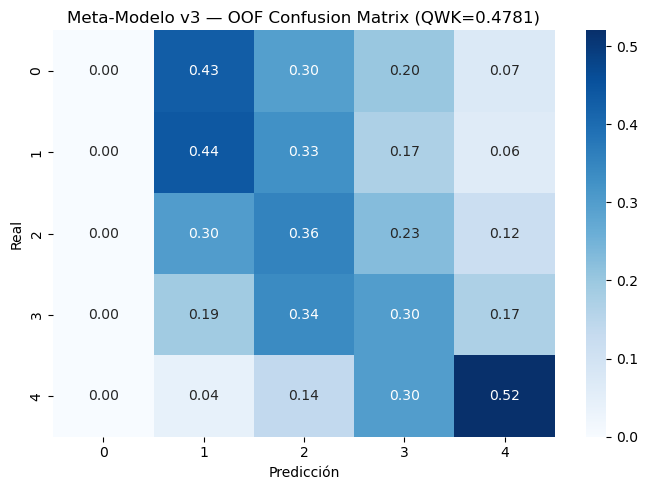

In [ ]:
labels_speed = {0:'Mismo día', 1:'1-7 días', 2:'8-30 días', 3:'31-90 días', 4:'No adoptado'}

print('='*65)
print('  COMPARACIÓN DE RESULTADOS OOF')
print('='*65)
print(f'  [v1] Promedio ponderado dinámico : 0.3506')
print(f'  [v2] Meta Ridge + Optuna         : 0.3786')
print(f'  [v3] Meta LGBM + RescuerID       : {qwk_opt_final:.4f}')
print(f'  Mejora v2 → v3 : {qwk_opt_final - 0.3786:+.4f}')
print(f'  Mejora v1 → v3 : {qwk_opt_final - 0.3506:+.4f}')
print('='*65)

print('\nReporte por clase:')
print(classification_report(
    y_ensemble, preds_opt_final,
    target_names=[f'Clase {i} ({labels_speed[i]})' for i in range(NUM_CLASSES)]))

# Diagnóstico de colapso a clase 2
print('\n[DIAG] Distribución de predicciones OOF (v3):')
unique, counts = np.unique(preds_opt_final, return_counts=True)
for cl, cnt in zip(unique, counts):
    pct = cnt / len(preds_opt_final) * 100
    bar = '█' * int(pct / 2)
    print(f'  Clase {cl}: {cnt:5d} ({pct:.1f}%) {bar}')
print('\n[DIAG] Si clase 2 bajó de ~40% → el colapso se redujo ✓')

# Matriz de confusión
cm = confusion_matrix(y_ensemble, preds_opt_final, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES), ax=ax)
ax.set_title(f'Meta-Modelo v3 — OOF Confusion Matrix (QWK={qwk_opt_final:.4f})')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(os.path.join(PATH_TO_WORK, 'confusion_matrix_v3_oof.png'), dpi=150)
plt.show()


## Sección 11 — Entrenamiento Final y Evaluación en Test



[FINAL] Entrenando ViT final sobre train completo...
  [IMG] Sin imagen: 272/11984 mascotas
  [IMG] Sin imagen: 272/11984 mascotas
    Epoch 1/8 | Val QWK: 0.0901
    Epoch 2/8 | Val QWK: 0.1059
    Epoch 3/8 | Val QWK: 0.1060
    Epoch 4/8 | Val QWK: 0.1060
    Epoch 5/8 | Val QWK: 0.1060
    Epoch 6/8 | Val QWK: 0.1060
    Epoch 7/8 | Val QWK: 0.1060
    Epoch 8/8 | Val QWK: 0.1060
[FINAL] ViT guardado ✓
[FINAL] Entrenando BERT final sobre train completo...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    Epoch 1/6 | Val QWK: 0.2565
    Epoch 2/6 | Val QWK: 0.4001
    Epoch 3/6 | Val QWK: 0.6439
    Epoch 4/6 | Val QWK: 0.7705
    Epoch 5/6 | Val QWK: 0.8283
    Epoch 6/6 | Val QWK: 0.8504
[FINAL] BERT guardado ✓

[TEST] Generando predicciones en test...
[WARN] Columnas object eliminadas antes de predecir: ['desc_lang']
  [IMG] Sin imagen: 68/2996 mascotas


BERT inference: 100%|██████████| 94/94 [00:05<00:00, 18.48it/s]



  RESULTADOS FINALES — META-MODELO v3
  QWK v1 (baseline) : 0.3506
  QWK v2 (Ridge)    : 0.3786
  QWK v3 (LGBM+RID) : 0.4159
  Mejora v2 → v3    : +0.0373
  Mejora v1 → v3    : +0.0653

Reporte por clase (test):
                       precision    recall  f1-score   support

  Clase 0 (Mismo día)       0.00      0.00      0.00        82
   Clase 1 (1-7 días)       0.35      0.39      0.37       618
  Clase 2 (8-30 días)       0.33      0.38      0.35       805
 Clase 3 (31-90 días)       0.24      0.28      0.26       652
Clase 4 (No adoptado)       0.63      0.46      0.53       839

             accuracy                           0.37      2996
            macro avg       0.31      0.30      0.30      2996
         weighted avg       0.39      0.37      0.37      2996


[DIAG] Distribución de predicciones en test:
  Clase 1:   681 (22.7%) ███████████
  Clase 2:   922 (30.8%) ███████████████
  Clase 3:   785 (26.2%) █████████████
  Clase 4:   608 (20.3%) ██████████


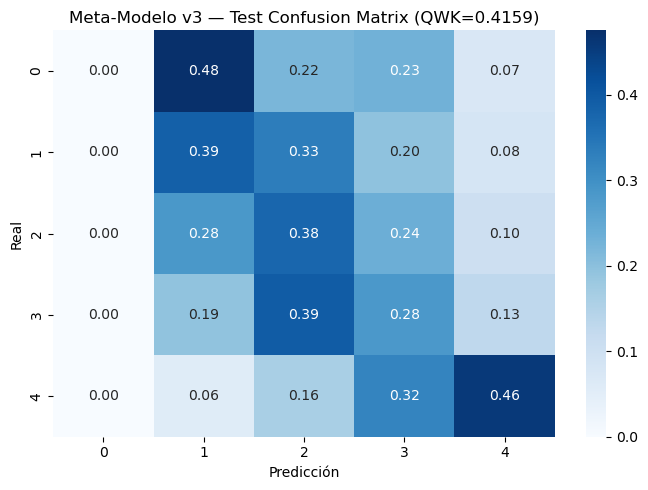

In [ ]:
# =============================================================================
#  SECCIÓN 11 — ENTRENAMIENTO FINAL Y EVALUACIÓN EN TEST
# =============================================================================

def predict_tabular_v3(models_ord, models_clf, df, cat_encoders):
    """Genera scores ordinales y probabilidades para test."""
    X_test, _ = prepare_lgb_features(df, cat_encoders=cat_encoders, fit=False)

    # ── Fix: eliminar columnas object que no fueron encodeadas ────────────────
    # desc_lang u otras columnas string que no están en CAT_COLS ni DROP_COLS
    # quedan con dtype object y LightGBM las rechaza al momento de predecir.
    object_cols = X_test.select_dtypes(include=['object']).columns.tolist()
    if object_cols:
        print(f'[WARN] Columnas object eliminadas antes de predecir: {object_cols}')
        X_test = X_test.drop(columns=object_cols)

    scores = np.mean([m.predict(X_test) for m in models_ord], axis=0)
    probas = np.mean([m.predict_proba(X_test) for m in models_clf], axis=0)
    return scores, probas


def predict_vit_final(model, df, images_dir):
    ds     = PetImageDataset(df, images_dir, transform=val_transforms)
    loader = DataLoader(ds, batch_size=VIT_BATCH, shuffle=False,
                        num_workers=CPU_CORES, pin_memory=AMP)
    model.eval()
    result = {}
    with torch.no_grad():
        for imgs, labels, pids in tqdm(loader, desc='ViT inference'):
            with torch.cuda.amp.autocast(enabled=AMP):
                logits = model(imgs.to(DEVICE))
            probas = F.softmax(logits, dim=1).cpu().numpy()
            for pid, p in zip(pids, probas):
                result[pid] = p
    return result


def predict_bert_final(model, df, tokenizer):
    ds     = PetTextDataset(df, tokenizer)
    loader = DataLoader(ds, batch_size=BERT_BATCH, shuffle=False,
                        num_workers=0, pin_memory=AMP)
    model.eval()
    result = {}
    with torch.no_grad():
        for batch in tqdm(loader, desc='BERT inference'):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            with torch.cuda.amp.autocast(enabled=AMP):
                logits = model(input_ids=ids, attention_mask=mask).logits
            probas = F.softmax(logits, dim=1).cpu().numpy()
            for pid, p in zip(batch['pet_id'], probas):
                result[pid] = p
    return result


# ── Entrenar modelos finales sobre train completo ─────────────────────────────
print('[FINAL] Entrenando ViT final sobre train completo...')
vit_final_cw = compute_class_weights_sqrt(train_text['AdoptionSpeed'].values)
full_vit_ds  = PetImageDataset(train_text, PATH_TO_IMAGES_DIR, transform=train_transforms)
full_vit_dl  = DataLoader(full_vit_ds, batch_size=VIT_BATCH,
                           sampler=make_weighted_sampler(
                               [s[1] for s in full_vit_ds.samples]),
                           num_workers=CPU_CORES, pin_memory=AMP)
eval_vit_dl  = DataLoader(
    PetImageDataset(train_text, PATH_TO_IMAGES_DIR, transform=val_transforms),
    batch_size=VIT_BATCH, shuffle=False,
    num_workers=CPU_CORES, pin_memory=AMP)

vit_final = build_vit()
_ = train_vit_one_fold(
    vit_final, full_vit_dl, eval_vit_dl,
    num_epochs=8, lr=VIT_LR * 0.1,
    class_weights_tensor=torch.tensor(vit_final_cw, dtype=torch.float32))
torch.save(vit_final.state_dict(), os.path.join(PATH_TO_WORK, 'vit_final.pth'))
print('[FINAL] ViT guardado ✓')


print('[FINAL] Entrenando BERT final sobre train completo...')
tokenizer_final = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)
bert_final_cw   = compute_class_weights_sqrt(train_text['AdoptionSpeed'].values)
full_bert_ds    = PetTextDataset(train_text, tokenizer_final)
full_bert_dl    = DataLoader(full_bert_ds, batch_size=BERT_BATCH,
                              shuffle=True, num_workers=0, pin_memory=AMP)

bert_final = build_distilbert()
_ = train_bert_one_fold(
    bert_final, full_bert_dl, full_bert_dl,
    num_epochs=BERT_EPOCHS + 2,
    class_weights_tensor=torch.tensor(bert_final_cw, dtype=torch.float32))
torch.save(bert_final.state_dict(), os.path.join(PATH_TO_WORK, 'bert_final.pth'))
print('[FINAL] BERT guardado ✓')


# ── Predicciones en test ──────────────────────────────────────────────────────
print('\n[TEST] Generando predicciones en test...')

# Limpiar test_df_full: columnas object que LightGBM no acepta
test_df_full_encoded = test_df_full.copy()

# desc_lang y cualquier otra columna object: convertir a string
# (prepare_lgb_features + predict_tabular_v3 se encargan de dropearlas)
for col in test_df_full_encoded.select_dtypes(include=['object']).columns:
    if col not in ['Name', 'Description', 'PetID', 'RescuerID']:
        test_df_full_encoded[col] = test_df_full_encoded[col].astype(str)

test_tab_scores, test_tab_proba = predict_tabular_v3(
    tab_models_ord, tab_models_clf,
    test_df_full_encoded, tab_cat_enc)

vit_test_dict  = predict_vit_final(vit_final,  test_text, PATH_TO_IMAGES_DIR)
bert_test_dict = predict_bert_final(bert_final, test_text, tokenizer_final)


# ── Alinear predicciones por PetID ───────────────────────────────────────────
test_pid_list = test_text['PetID'].tolist()
tab_test_map  = {pid: i for i, pid in enumerate(test_df_full['PetID'])}

p_tab_test  = np.array([test_tab_proba[tab_test_map[pid]] if pid in tab_test_map else UNIF
                         for pid in test_pid_list])
s_tab_test  = np.array([test_tab_scores[tab_test_map[pid]] if pid in tab_test_map else 2.0
                         for pid in test_pid_list])
p_vit_test  = np.array([vit_test_dict.get(pid,  UNIF) for pid in test_pid_list])
p_bert_test = np.array([bert_test_dict.get(pid, UNIF) for pid in test_pid_list])


# ── Calibración con calibradores finales ─────────────────────────────────────
# ✅ iso_tab_final / iso_vit_final / iso_bert_final ajustados sobre todo el train
p_tab_test_cal  = apply_isotonic_calibration(p_tab_test,  iso_tab_final)
p_vit_test_cal  = apply_isotonic_calibration(p_vit_test,  iso_vit_final)
p_bert_test_cal = apply_isotonic_calibration(p_bert_test, iso_bert_final)


# ── Meta-modelo y thresholds ──────────────────────────────────────────────────
X_meta_test      = build_meta_features(
    p_tab_test_cal, p_vit_test_cal, p_bert_test_cal, s_tab_test)
meta_scores_test = meta_model_final.predict(X_meta_test)
preds_test_final = apply_thresholds(meta_scores_test, BEST_THRESHOLDS)


# ── Evaluación ────────────────────────────────────────────────────────────────
y_test_aligned = test_text['AdoptionSpeed'].values
qwk_final = cohen_kappa_score(y_test_aligned, preds_test_final, weights='quadratic')

print(f'\n{"="*65}')
print(f'  RESULTADOS FINALES — META-MODELO v3')
print(f'{"="*65}')
print(f'  QWK v1 (baseline) : 0.3506')
print(f'  QWK v2 (Ridge)    : 0.3786')
print(f'  QWK v3 (LGBM+RID) : {qwk_final:.4f}')
print(f'  Mejora v2 → v3    : {qwk_final - 0.3786:+.4f}')
print(f'  Mejora v1 → v3    : {qwk_final - 0.3506:+.4f}')
print(f'{"="*65}')

print('\nReporte por clase (test):')
print(classification_report(
    y_test_aligned, preds_test_final,
    target_names=[f'Clase {i} ({labels_speed[i]})' for i in range(NUM_CLASSES)]))

print('\n[DIAG] Distribución de predicciones en test:')
unique, counts_pred = np.unique(preds_test_final, return_counts=True)
for cl, cnt in zip(unique, counts_pred):
    pct = cnt / len(preds_test_final) * 100
    bar = '█' * int(pct / 2)
    print(f'  Clase {cl}: {cnt:5d} ({pct:.1f}%) {bar}')

cm = confusion_matrix(y_test_aligned, preds_test_final, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES), ax=ax)
ax.set_title(f'Meta-Modelo v3 — Test Confusion Matrix (QWK={qwk_final:.4f})')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(os.path.join(PATH_TO_WORK, 'confusion_matrix_v3_test.png'), dpi=150)
plt.show()

## 12. Guardar configuración final

In [ ]:
final_config = {
    'version':       'v3',
    'cambios_vs_v2': [
        '[A] Class weights: 1/sqrt(n) en lugar de 1/n — clase 0 recibe ~3x no ~10x',
        '[B] Meta-modelo: LGBMRegressor en lugar de RidgeCV — no-lineal',
        '[C] CV anidado CON calibración interna: sin leakage entre calibración y meta-modelo',
        '[D] 19 features en meta-modelo: +fast_signal, +slow_signal, +acuerdo_tab_vit',
        '[E] ~22 features nuevas de RescuerID: volumen, calidad, diversidad, historial, posición relativa, target encoding con smoothing',
    ],
    'rescuerid_features': [
        'rescuer_n_pets', 'rescuer_quantity_sum', 'rescuer_quantity_mean',
        'is_prolific_rescuer', 'is_batch_rescuer',
        'rescuer_photo_mean', 'rescuer_photo_std',
        'rescuer_fee_mean', 'rescuer_pct_free', 'rescuer_pct_has_desc', 'rescuer_pct_has_video',
        'rescuer_n_breeds', 'rescuer_n_states', 'rescuer_n_types', 'rescuer_breed_diversity',
        'rescuer_pct_vaccinated', 'rescuer_pct_sterilized', 'rescuer_pct_dewormed',
        'rescuer_health_score',
        'rescuer_age_mean', 'rescuer_age_std', 'age_vs_rescuer_mean', 'age_vs_rescuer_std',
        'rescuer_maturity_mean', 'rescuer_mean_speed (target enc con smoothing=10)',
    ],
    'qwk_v1': 0.3506,
    'qwk_v2': 0.3786,
    'qwk_v3_oof_sin_leakage': float(qwk_opt_final),
    'nota_leakage': 'calibracion isotonica ajustada dentro del CV anidado, no sobre todos los OOF',
    'best_thresholds': BEST_THRESHOLDS.tolist(),
    'lgb_meta_params': LGB_PARAMS_META,
    'lgb_ordinal_params': LGB_PARAMS_ORDINAL,
    'lgb_clf_params': LGB_PARAMS_CLF,
}

with open(os.path.join(PATH_TO_WORK, 'final_config_v3.json'), 'w') as f:
    json.dump(final_config, f, indent=2)

print('✅ Pipeline v3 completo.')
print(f'   Archivos en: {PATH_TO_WORK}')
print(f'   QWK OOF final: {qwk_opt_final:.4f}')
print(f'   Cambios [A][B][C][D][E] aplicados.')


✅ Pipeline v3 completo.
   Archivos en: C:\Users\Usuario\Desktop\Maestría en ciencia de datos- Austral\1- Primer año\11- Laboratorio 2\TP 2\Documental\outputs
   QWK OOF final: 0.4781
   Cambios [A][B][C][D][E] aplicados.
